# 05 - Valid Model Improvement Pipeline

## Step 1: Load data, freeze features, and create valid stratified splits

This notebook rebuilds the modelling workflow in a clean and valid way.

### Goal of this step
In this first step, we only:
- load the modelling dataset
- freeze the final modelling feature set
- audit checkpoint sizes, class balance, and missing values
- split the data separately for each checkpoint using stratified train/test split
- store reusable train/test datasets for later modelling

### Why this step matters
Previously, the modelling workflow had issues because the test data influenced model selection.
So before tuning CatBoost, Logistic Regression, XGBoost, and Random Forest, we first create a strict and reusable split foundation.

### What this step does not do
This step does **not**:
- train any model
- tune hyperparameters
- calibrate probabilities
- tune thresholds

It only prepares a correct base for all later experiments.

In [125]:
# =========================
# Step 1: Data + checkpoint-wise stratified split foundation
# =========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split

# -------------------------
# 1. Config
# -------------------------
# Find project root
cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd.parent.parent / "data").exists():
    PROJECT_ROOT = cwd.parent.parent
else:
    raise FileNotFoundError("Could not find project root containing the data/ folder.")

# Load final modelling dataset
model_path = PROJECT_ROOT / "data" / "processed" / "bbl_model_dataset_with_elo.csv"

DATA_PATH = Path(model_path)

TARGET_COL = "target_batfirst"
CHECKPOINTS = [6, 10, 15, 20]

FEATURE_COLS = [
    "wickets",
    "run_rate",
    "momentum_runs",
    "momentum_wickets",
    "venue",
    "resource_frac",
    "venue_mean_runs_cp",
    "venue_mean_wkts_cp",
    "season_mean_runs_cp",
    "season_mean_wkts_cp",
    "elo_diff",
]

META_COLS = ["match_id", "season", "checkpoint", TARGET_COL]
REQUIRED_COLS = META_COLS + FEATURE_COLS

TEST_SIZE = 0.20
RANDOM_STATE = 42

# -------------------------
# 2. Load data
# -------------------------
df = pd.read_csv(DATA_PATH)

print("=" * 80)
print("FULL DATASET LOADED")
print("=" * 80)
print(f"Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print()

# -------------------------
# 3. Validate required columns
# -------------------------
missing_required = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

work_df = df[REQUIRED_COLS].copy()

print("=" * 80)
print("WORKING DATAFRAME")
print("=" * 80)
print(f"Shape after selecting required columns: {work_df.shape}")
print()

# -------------------------
# 4. Overall sanity checks
# -------------------------
print("=" * 80)
print("OVERALL SANITY CHECKS")
print("=" * 80)

print("Checkpoint counts:")
print(work_df["checkpoint"].value_counts().sort_index())
print()

print("Target distribution (overall):")
print(work_df[TARGET_COL].value_counts(dropna=False).sort_index())
print()
print("Target distribution (overall proportion):")
print(work_df[TARGET_COL].value_counts(normalize=True, dropna=False).sort_index().round(4))
print()

# -------------------------
# 5. Missing value audit
# -------------------------
print("=" * 80)
print("MISSING VALUE AUDIT - OVERALL")
print("=" * 80)

missing_overall = work_df.isna().sum().sort_values(ascending=False)
missing_overall = missing_overall[missing_overall > 0]

if len(missing_overall) == 0:
    print("No missing values in required columns.")
else:
    print(missing_overall)
print()

print("=" * 80)
print("MISSING VALUE AUDIT - BY CHECKPOINT")
print("=" * 80)

for cp in CHECKPOINTS:
    cp_df = work_df[work_df["checkpoint"] == cp].copy()
    cp_missing = cp_df.isna().sum()
    cp_missing = cp_missing[cp_missing > 0].sort_values(ascending=False)

    print(f"\nCheckpoint {cp}")
    print(f"Rows: {len(cp_df)}")

    if len(cp_missing) == 0:
        print("No missing values")
    else:
        print(cp_missing)

# -------------------------
# 6. Build checkpoint-wise stratified splits
# -------------------------
checkpoint_splits = {}
summary_rows = []

for cp in CHECKPOINTS:
    cp_df = work_df[work_df["checkpoint"] == cp].copy().reset_index(drop=True)

    # Optional sanity check: one row per match per checkpoint
    dup_count = cp_df.duplicated(subset=["match_id"]).sum()
    if dup_count > 0:
        print(f"Warning: Checkpoint {cp} has {dup_count} duplicated match_id values.")

    train_df, test_df = train_test_split(
        cp_df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=cp_df[TARGET_COL]
    )

    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    X_train = train_df[FEATURE_COLS].copy()
    y_train = train_df[TARGET_COL].copy()

    X_test = test_df[FEATURE_COLS].copy()
    y_test = test_df[TARGET_COL].copy()

    checkpoint_splits[cp] = {
        "full_df": cp_df,
        "train_df": train_df,
        "test_df": test_df,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
    }

    summary_rows.append({
        "checkpoint": cp,
        "total_rows": len(cp_df),
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "train_class_0": int((y_train == 0).sum()),
        "train_class_1": int((y_train == 1).sum()),
        "test_class_0": int((y_test == 0).sum()),
        "test_class_1": int((y_test == 1).sum()),
        "train_pos_rate": round(y_train.mean(), 4),
        "test_pos_rate": round(y_test.mean(), 4),
    })

split_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 80)
print("CHECKPOINT-WISE STRATIFIED SPLIT SUMMARY")
print("=" * 80)
display(split_summary)

# -------------------------
# 7. Helper function for later steps
# -------------------------
def get_checkpoint_data(checkpoint: int):
    """
    Return checkpoint-specific split objects from the frozen stratified split.
    """
    if checkpoint not in CHECKPOINTS:
        raise ValueError(f"Checkpoint must be one of {CHECKPOINTS}")

    obj = checkpoint_splits[checkpoint]
    return (
        obj["train_df"],
        obj["test_df"],
        obj["X_train"],
        obj["y_train"],
        obj["X_test"],
        obj["y_test"],
    )

# -------------------------
# 8. Preview one checkpoint
# -------------------------
cp = 15
train_df_cp, test_df_cp, X_train_cp, y_train_cp, X_test_cp, y_test_cp = get_checkpoint_data(cp)

print("\n" + "=" * 80)
print(f"CHECKPOINT {cp} PREVIEW")
print("=" * 80)
print(f"Train shape: {train_df_cp.shape}")
print(f"Test shape: {test_df_cp.shape}")
print(f"X_train shape: {X_train_cp.shape}")
print(f"X_test shape: {X_test_cp.shape}")
print()

print("Train target distribution:")
print(y_train_cp.value_counts(dropna=False).sort_index())
print()

print("Test target distribution:")
print(y_test_cp.value_counts(dropna=False).sort_index())
print()

print("Missing values in X_train:")
train_missing = X_train_cp.isna().sum()
print(train_missing[train_missing > 0] if (train_missing > 0).any() else "No missing values")
print()

print("Missing values in X_test:")
test_missing = X_test_cp.isna().sum()
print(test_missing[test_missing > 0] if (test_missing > 0).any() else "No missing values")

FULL DATASET LOADED
Shape: (2404, 39)
Columns: 39

WORKING DATAFRAME
Shape after selecting required columns: (2404, 15)

OVERALL SANITY CHECKS
Checkpoint counts:
checkpoint
6     618
10    613
15    601
20    572
Name: count, dtype: int64

Target distribution (overall):
target_batfirst
0    1260
1    1144
Name: count, dtype: int64

Target distribution (overall proportion):
target_batfirst
0    0.5241
1    0.4759
Name: proportion, dtype: float64

MISSING VALUE AUDIT - OVERALL
elo_diff    39
dtype: int64

MISSING VALUE AUDIT - BY CHECKPOINT

Checkpoint 6
Rows: 618
elo_diff    14
dtype: int64

Checkpoint 10
Rows: 613
elo_diff    10
dtype: int64

Checkpoint 15
Rows: 601
elo_diff    8
dtype: int64

Checkpoint 20
Rows: 572
elo_diff    7
dtype: int64

CHECKPOINT-WISE STRATIFIED SPLIT SUMMARY


,checkpoint,total_rows,train_rows,test_rows,train_class_0,train_class_1,test_class_0,test_class_1,train_pos_rate,test_pos_rate
0,6,618,494,124,261,233,66,58,0.4717,0.4677
1,10,613,490,123,258,232,65,58,0.4735,0.4715
2,15,601,480,121,252,228,63,58,0.4750,0.4793
3,20,572,457,115,236,221,59,56,0.4836,0.4870



CHECKPOINT 15 PREVIEW
Train shape: (480, 15)
Test shape: (121, 15)
X_train shape: (480, 11)
X_test shape: (121, 11)

Train target distribution:
target_batfirst
0    252
1    228
Name: count, dtype: int64

Test target distribution:
target_batfirst
0    63
1    58
Name: count, dtype: int64

Missing values in X_train:
elo_diff    6
dtype: int64

Missing values in X_test:
elo_diff    2
dtype: int64


## Step 2: Build clean baseline pipelines for all 4 models and all 4 checkpoints

### Goal of this step
In this step, we:
- create leak-safe preprocessing inside sklearn pipelines
- define baseline versions of:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - CatBoost
- evaluate them on all 4 checkpoints using the frozen stratified splits from Step 1
- collect test metrics in one comparison table

### Why this step matters
Before tuning, calibration, threshold moving, or class weights, we need a proper baseline.
This gives us a fair benchmark so we can later measure whether each improvement is truly helping.

### Rules for this step
- No hyperparameter tuning
- No calibration
- No threshold tuning
- No test-set-based model selection
- Test set is used only once per fitted baseline model

In [126]:
# =========================
# Step 2: Clean baseline models across all checkpoints
# =========================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# -------------------------
# 1. Feature groups
# -------------------------
CAT_COLS = ["venue"]
NUM_COLS = [c for c in FEATURE_COLS if c not in CAT_COLS]

print("Categorical columns:", CAT_COLS)
print("Numeric columns:", NUM_COLS)
print()

# -------------------------
# 2. Preprocessors
# -------------------------
# For Logistic Regression: median impute + scale numeric, OHE categorical
log_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), NUM_COLS),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), CAT_COLS),
    ],
    remainder="drop"
)

# For RF/XGB: median impute numeric, ordinal encode categorical
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), NUM_COLS),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), CAT_COLS),
    ],
    remainder="drop"
)

# -------------------------
# 3. Baseline model pipelines
# -------------------------
baseline_models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", log_preprocessor),
        ("model", LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            random_state=42
        ))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "XGBoost": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]),
}

# -------------------------
# 4. CatBoost helper
# -------------------------
def fit_evaluate_catboost(X_train, y_train, X_test, y_test):
    X_train_cb = X_train.copy()
    X_test_cb = X_test.copy()

    # Fill missing values explicitly for CatBoost baseline
    for col in NUM_COLS:
        median_val = X_train_cb[col].median()
        X_train_cb[col] = X_train_cb[col].fillna(median_val)
        X_test_cb[col] = X_test_cb[col].fillna(median_val)

    for col in CAT_COLS:
        mode_val = X_train_cb[col].mode(dropna=True)
        fill_val = mode_val.iloc[0] if len(mode_val) > 0 else "missing"
        X_train_cb[col] = X_train_cb[col].fillna(fill_val).astype(str)
        X_test_cb[col] = X_test_cb[col].fillna(fill_val).astype(str)

    cat_features_idx = [X_train_cb.columns.get_loc(c) for c in CAT_COLS]

    model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=42
    )

    model.fit(X_train_cb, y_train, cat_features=cat_features_idx)

    y_prob = model.predict_proba(X_test_cb)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

# -------------------------
# 5. Generic sklearn model evaluator
# -------------------------
def fit_evaluate_sklearn_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

# -------------------------
# 6. Run baseline evaluation for all checkpoints
# -------------------------
all_results = []

for cp in CHECKPOINTS:
    print("=" * 80)
    print(f"RUNNING BASELINES FOR CHECKPOINT {cp}")
    print("=" * 80)

    train_df_cp, test_df_cp, X_train_cp, y_train_cp, X_test_cp, y_test_cp = get_checkpoint_data(cp)

    # sklearn models
    for model_name, model in baseline_models.items():
        result = fit_evaluate_sklearn_model(model, X_train_cp, y_train_cp, X_test_cp, y_test_cp)

        row = {
            "checkpoint": cp,
            "model": model_name,
            **{k: round(v, 4) if isinstance(v, float) else v for k, v in result.items()}
        }
        all_results.append(row)

        print(f"{model_name:<22} | Acc={result['accuracy']:.4f} | F1={result['f1']:.4f} | "
              f"AUC={result['auc']:.4f} | TN={result['tn']} FP={result['fp']} FN={result['fn']} TP={result['tp']}")

    # CatBoost
    cb_result = fit_evaluate_catboost(X_train_cp, y_train_cp, X_test_cp, y_test_cp)

    row = {
        "checkpoint": cp,
        "model": "CatBoost",
        **{k: round(v, 4) if isinstance(v, float) else v for k, v in cb_result.items()}
    }
    all_results.append(row)

    print(f"{'CatBoost':<22} | Acc={cb_result['accuracy']:.4f} | F1={cb_result['f1']:.4f} | "
          f"AUC={cb_result['auc']:.4f} | TN={cb_result['tn']} FP={cb_result['fp']} FN={cb_result['fn']} TP={cb_result['tp']}")
    print()

baseline_results_df = pd.DataFrame(all_results)

print("=" * 80)
print("FINAL BASELINE RESULTS TABLE")
print("=" * 80)
display(baseline_results_df.sort_values(["checkpoint", "accuracy"], ascending=[True, False]).reset_index(drop=True))

print("\n" + "=" * 80)
print("BEST MODEL PER CHECKPOINT BY ACCURACY")
print("=" * 80)
best_per_cp = (
    baseline_results_df
    .sort_values(["checkpoint", "accuracy"], ascending=[True, False])
    .groupby("checkpoint", as_index=False)
    .first()
)
display(best_per_cp)

print("\n" + "=" * 80)
print("CATBOOST ONLY SUMMARY")
print("=" * 80)
display(
    baseline_results_df[baseline_results_df["model"] == "CatBoost"]
    .sort_values("checkpoint")
    .reset_index(drop=True)
)

Categorical columns: ['venue']
Numeric columns: ['wickets', 'run_rate', 'momentum_runs', 'momentum_wickets', 'resource_frac', 'venue_mean_runs_cp', 'venue_mean_wkts_cp', 'season_mean_runs_cp', 'season_mean_wkts_cp', 'elo_diff']

RUNNING BASELINES FOR CHECKPOINT 6
Logistic Regression    | Acc=0.6452 | F1=0.6071 | AUC=0.6980 | TN=46 FP=20 FN=24 TP=34
Random Forest          | Acc=0.6048 | F1=0.5664 | AUC=0.6450 | TN=43 FP=23 FN=26 TP=32
XGBoost                | Acc=0.5968 | F1=0.5690 | AUC=0.6296 | TN=41 FP=25 FN=25 TP=33
CatBoost               | Acc=0.6129 | F1=0.5472 | AUC=0.6403 | TN=47 FP=19 FN=29 TP=29

RUNNING BASELINES FOR CHECKPOINT 10
Logistic Regression    | Acc=0.6504 | F1=0.6195 | AUC=0.6602 | TN=45 FP=20 FN=23 TP=35
Random Forest          | Acc=0.5610 | F1=0.5263 | AUC=0.6489 | TN=39 FP=26 FN=28 TP=30
XGBoost                | Acc=0.5528 | F1=0.5378 | AUC=0.6305 | TN=36 FP=29 FN=26 TP=32
CatBoost               | Acc=0.5854 | F1=0.5565 | AUC=0.6485 | TN=40 FP=25 FN=26 TP=32

RU

,checkpoint,model,accuracy,f1,auc,tn,fp,fn,tp
0,6,Logistic Regression,0.6452,0.6071,0.6980,46,20,24,34
1,6,CatBoost,0.6129,0.5472,0.6403,47,19,29,29
2,6,Random Forest,0.6048,0.5664,0.6450,43,23,26,32
3,6,XGBoost,0.5968,0.5690,0.6296,41,25,25,33
4,10,Logistic Regression,0.6504,0.6195,0.6602,45,20,23,35
5,10,CatBoost,0.5854,0.5565,0.6485,40,25,26,32
6,10,Random Forest,0.5610,0.5263,0.6489,39,26,28,30
7,10,XGBoost,0.5528,0.5378,0.6305,36,29,26,32
8,15,Logistic Regression,0.6529,0.6500,0.7066,40,23,19,39
9,15,Random Forest,0.6364,0.6452,0.6736,37,26,18,40



BEST MODEL PER CHECKPOINT BY ACCURACY


,checkpoint,model,accuracy,f1,auc,tn,fp,fn,tp
0,6,Logistic Regression,0.6452,0.6071,0.6980,46,20,24,34
1,10,Logistic Regression,0.6504,0.6195,0.6602,45,20,23,35
2,15,Logistic Regression,0.6529,0.6500,0.7066,40,23,19,39
3,20,Logistic Regression,0.6696,0.6724,0.7079,38,21,17,39



CATBOOST ONLY SUMMARY


,checkpoint,model,accuracy,f1,auc,tn,fp,fn,tp
0,6,CatBoost,0.6129,0.5472,0.6403,47,19,29,29
1,10,CatBoost,0.5854,0.5565,0.6485,40,25,26,32
2,15,CatBoost,0.5868,0.5968,0.6440,34,29,21,37
3,20,CatBoost,0.6174,0.5686,0.7013,42,17,27,29


## Step 3: Tune Logistic Regression with inner CV on training only

### Goal of this step
In this step, we:
- keep the outer test split untouched
- tune Logistic Regression using only the training split
- run the same tuning process for all 4 checkpoints
- compare tuned test performance against the baseline Logistic Regression results

### Why this step matters
Logistic Regression is currently the strongest clean baseline across all checkpoints.
So before moving to more complex models, we first check how much improvement we can get from a properly tuned linear model.

### What we will tune
We will tune:
- regularization strength `C`
- penalty type
- solver
- class weight

### Rules
- inner CV uses training data only
- outer test set is touched only once at final evaluation
- no calibration yet
- no threshold tuning yet

In [127]:
# =========================
# Step 3: Tune Logistic Regression across all checkpoints
# =========================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from IPython.display import display

# -------------------------
# 1. Inner CV setup
# -------------------------
inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -------------------------
# 2. Logistic pipeline
# -------------------------
log_tuning_pipeline = Pipeline([
    ("preprocessor", log_preprocessor),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

# -------------------------
# 3. Parameter grid
# -------------------------
log_param_grid = [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1.0, 3.0, 10.0],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.1, 1.0, 3.0, 10.0],
        "model__class_weight": [None, "balanced"]
    }
]

# -------------------------
# 4. Tuning loop
# -------------------------
log_tuned_results = []

for cp in CHECKPOINTS:
    print("=" * 80)
    print(f"TUNING LOGISTIC REGRESSION FOR CHECKPOINT {cp}")
    print("=" * 80)

    train_df_cp, test_df_cp, X_train_cp, y_train_cp, X_test_cp, y_test_cp = get_checkpoint_data(cp)

    grid = GridSearchCV(
        estimator=log_tuning_pipeline,
        param_grid=log_param_grid,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
            "auc": "roc_auc"
        },
        refit="accuracy",
        cv=inner_cv,
        n_jobs=-1,
        verbose=0,
        return_train_score=False
    )

    grid.fit(X_train_cp, y_train_cp)

    best_model = grid.best_estimator_
    y_prob = best_model.predict_proba(X_test_cp)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_test_cp, y_pred)
    tn, fp, fn, tp = cm.ravel()

    row = {
        "checkpoint": cp,
        "best_params": grid.best_params_,
        "cv_accuracy_mean": round(grid.best_score_, 4),
        "cv_f1_mean": round(grid.cv_results_["mean_test_f1"][grid.best_index_], 4),
        "cv_auc_mean": round(grid.cv_results_["mean_test_auc"][grid.best_index_], 4),
        "test_accuracy": round(accuracy_score(y_test_cp, y_pred), 4),
        "test_f1": round(f1_score(y_test_cp, y_pred), 4),
        "test_auc": round(roc_auc_score(y_test_cp, y_prob), 4),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

    log_tuned_results.append(row)

    print("Best params:")
    print(grid.best_params_)
    print(f"Best CV accuracy: {grid.best_score_:.4f}")
    print(f"Test accuracy: {accuracy_score(y_test_cp, y_pred):.4f}")
    print(f"Test F1: {f1_score(y_test_cp, y_pred):.4f}")
    print(f"Test AUC: {roc_auc_score(y_test_cp, y_prob):.4f}")
    print(f"Confusion matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print()

log_tuned_results_df = pd.DataFrame(log_tuned_results)

print("=" * 80)
print("TUNED LOGISTIC REGRESSION RESULTS")
print("=" * 80)
display(log_tuned_results_df)

# -------------------------
# 5. Compare with baseline logistic regression
# -------------------------
baseline_log_df = (
    baseline_results_df[baseline_results_df["model"] == "Logistic Regression"]
    .copy()
    .rename(columns={
        "accuracy": "baseline_accuracy",
        "f1": "baseline_f1",
        "auc": "baseline_auc",
        "tn": "baseline_tn",
        "fp": "baseline_fp",
        "fn": "baseline_fn",
        "tp": "baseline_tp"
    })
)

comparison_df = baseline_log_df.merge(
    log_tuned_results_df,
    on="checkpoint",
    how="inner"
)

comparison_df["accuracy_gain"] = (comparison_df["test_accuracy"] - comparison_df["baseline_accuracy"]).round(4)
comparison_df["f1_gain"] = (comparison_df["test_f1"] - comparison_df["baseline_f1"]).round(4)
comparison_df["auc_gain"] = (comparison_df["test_auc"] - comparison_df["baseline_auc"]).round(4)
comparison_df["fp_change"] = comparison_df["fp"] - comparison_df["baseline_fp"]
comparison_df["fn_change"] = comparison_df["fn"] - comparison_df["baseline_fn"]

comparison_cols = [
    "checkpoint",
    "baseline_accuracy", "test_accuracy", "accuracy_gain",
    "baseline_f1", "test_f1", "f1_gain",
    "baseline_auc", "test_auc", "auc_gain",
    "baseline_fp", "fp", "fp_change",
    "baseline_fn", "fn", "fn_change",
    "best_params"
]

print("\n" + "=" * 80)
print("BASELINE VS TUNED LOGISTIC REGRESSION")
print("=" * 80)
display(comparison_df[comparison_cols].sort_values("checkpoint").reset_index(drop=True))

TUNING LOGISTIC REGRESSION FOR CHECKPOINT 6
Best params:
{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV accuracy: 0.6336
Test accuracy: 0.6613
Test F1: 0.6111
Test AUC: 0.7194
Confusion matrix: TN=49, FP=17, FN=25, TP=33

TUNING LOGISTIC REGRESSION FOR CHECKPOINT 10
Best params:
{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV accuracy: 0.7143
Test accuracy: 0.6341
Test F1: 0.5872
Test AUC: 0.6759
Confusion matrix: TN=46, FP=19, FN=26, TP=32

TUNING LOGISTIC REGRESSION FOR CHECKPOINT 15
Best params:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV accuracy: 0.7104
Test accuracy: 0.6529
Test F1: 0.6557
Test AUC: 0.7096
Confusion matrix: TN=39, FP=24, FN=18, TP=40

TUNING LOGISTIC REGRESSION FOR CHECKPOINT 20
Best params:
{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__so

,checkpoint,best_params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,6,"{'model__C': 0.01, 'model__class_weight': None...",0.6336,0.6018,0.6691,0.6613,0.6111,0.7194,49,17,25,33
1,10,"{'model__C': 0.01, 'model__class_weight': None...",0.7143,0.6813,0.7473,0.6341,0.5872,0.6759,46,19,26,32
2,15,"{'model__C': 0.1, 'model__class_weight': 'bala...",0.7104,0.6953,0.7727,0.6529,0.6557,0.7096,39,24,18,40
3,20,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.7134,0.7011,0.7725,0.6087,0.6281,0.6946,32,27,18,38



BASELINE VS TUNED LOGISTIC REGRESSION


,checkpoint,baseline_accuracy,test_accuracy,accuracy_gain,baseline_f1,test_f1,f1_gain,baseline_auc,test_auc,auc_gain,baseline_fp,fp,fp_change,baseline_fn,fn,fn_change,best_params
0,6,0.6452,0.6613,0.0161,0.6071,0.6111,0.0040,0.6980,0.7194,0.0214,20,17,-3,24,25,1,"{'model__C': 0.01, 'model__class_weight': None..."
1,10,0.6504,0.6341,-0.0163,0.6195,0.5872,-0.0323,0.6602,0.6759,0.0157,20,19,-1,23,26,3,"{'model__C': 0.01, 'model__class_weight': None..."
2,15,0.6529,0.6529,0.0000,0.6500,0.6557,0.0057,0.7066,0.7096,0.0030,23,24,1,19,18,-1,"{'model__C': 0.1, 'model__class_weight': 'bala..."
3,20,0.6696,0.6087,-0.0609,0.6724,0.6281,-0.0443,0.7079,0.6946,-0.0133,21,27,6,17,18,1,"{'model__C': 0.01, 'model__class_weight': 'bal..."


### Step 3 Summary: Logistic Regression tuning results

This step tested whether Logistic Regression could be improved using a clean inner cross-validation tuning process on the training data only.

The tuned model did not improve consistently across all checkpoints.

- **Checkpoint 6:** tuning helped.  
  Accuracy improved from **0.6452** to **0.6613**, and AUC improved from **0.6980** to **0.7194**.  
  False positives also reduced from **20** to **17**.

- **Checkpoint 10:** tuning did not help overall.  
  Accuracy dropped from **0.6504** to **0.6341**, and F1 also decreased.  
  AUC improved slightly, but the baseline model remained better.

- **Checkpoint 15:** tuning gave only a small benefit.  
  Accuracy stayed the same at **0.6529**, while F1 and AUC improved slightly.  
  This was only a marginal gain.

- **Checkpoint 20:** tuning made performance worse.  
  Accuracy dropped from **0.6696** to **0.6087**, and false positives increased from **21** to **27**.

### Interpretation
These results show that simple hyperparameter tuning alone does not reliably improve Logistic Regression for every checkpoint.  
The baseline Logistic Regression model was already strong, and in several cases the tuned version over-adjusted the decision boundary without giving better final test performance.

### Conclusion from this step
The tuned Logistic Regression model is **not adopted as the final model for all checkpoints**.  
Instead:

- the **baseline Logistic Regression** remains the main benchmark model
- the tuning experiment is kept as a valid diagnostic step
- the next improvements should focus on **calibration and threshold tuning**, rather than more Logistic Regression hyperparameter search

## Step 4: Logistic Regression threshold tuning without sigmoid calibration

Based on supervisor feedback, the earlier sigmoid calibration step was removed. Logistic Regression already applies the logistic/sigmoid function internally to produce class probabilities. Therefore, adding a separate sigmoid calibration layer is not necessary for this experiment.

Instead, this step focuses only on threshold tuning. The model still outputs probabilities, but the final class prediction depends on the probability cutoff. The default threshold is 0.50, meaning:

- probability >= 0.50 → predicted as bat-first win
- probability < 0.50 → predicted as bat-first loss

To improve the decision boundary, thresholds from 0.30 to 0.70 are tested using out-of-fold predictions from the training data only. The test set is not used for choosing the threshold.

The process is:

1. Use the best Logistic Regression hyperparameters selected in Step 3.
2. Generate out-of-fold predicted probabilities on the training set.
3. Select the best threshold using training-only out-of-fold predictions.
4. Refit the Logistic Regression model on the full training set.
5. Evaluate on the untouched test set using both:
   - default threshold 0.50
   - tuned threshold

This keeps the test set clean and avoids using test results to guide model selection.

In [128]:
# =========================
# Step 4: Logistic Regression threshold tuning without sigmoid calibration
# =========================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from IPython.display import display

# -------------------------
# 1. Helper functions
# -------------------------
def evaluate_probs(y_true, y_prob, threshold=0.5):
    """
    Evaluate probability outputs at a selected classification threshold.
    """
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def choose_best_threshold(y_true, y_prob, thresholds):
    """
    Select the best threshold using training-only out-of-fold probabilities.

    Primary objective:
    - maximise accuracy

    Tie-breakers:
    1. lower false positives
    2. higher F1-score
    3. higher true positives
    4. threshold closest to 0.50
    """
    rows = []

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        rows.append({
            "threshold": float(thr),
            "accuracy": accuracy_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred),
            "auc": roc_auc_score(y_true, y_prob),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "distance_from_05": abs(float(thr) - 0.50)
        })

    threshold_df = pd.DataFrame(rows)

    best_row = (
        threshold_df
        .sort_values(
            by=["accuracy", "fp", "f1", "tp", "distance_from_05"],
            ascending=[False, True, False, False, True]
        )
        .iloc[0]
    )

    return float(best_row["threshold"]), threshold_df


def build_best_logistic_pipeline_for_checkpoint(cp):
    """
    Rebuild the best Logistic Regression pipeline for a checkpoint
    using the best hyperparameters found in Step 3.
    """
    best_params = (
        log_tuned_results_df
        .loc[log_tuned_results_df["checkpoint"] == cp, "best_params"]
        .iloc[0]
    )

    model = clone(log_tuning_pipeline)
    model.set_params(**best_params)

    return model, best_params


# -------------------------
# 2. Threshold tuning config
# -------------------------
THRESHOLD_GRID = np.round(np.arange(0.30, 0.71, 0.01), 2)

# We reuse the same inner_cv from Step 3.
# This produces out-of-fold probabilities on the training data only.

# -------------------------
# 3. Run threshold tuning for all checkpoints
# -------------------------
step4_results = []
threshold_pick_rows = []
threshold_detail_tables = {}

for cp in CHECKPOINTS:
    print("=" * 90)
    print(f"STEP 4: LOGISTIC REGRESSION THRESHOLD TUNING FOR CHECKPOINT {cp}")
    print("=" * 90)

    train_df_cp, test_df_cp, X_train_cp, y_train_cp, X_test_cp, y_test_cp = get_checkpoint_data(cp)

    # Build best tuned LR pipeline from Step 3
    lr_model, best_params = build_best_logistic_pipeline_for_checkpoint(cp)

    print("Best Step 3 Logistic Regression params:")
    print(best_params)
    print()

    # -------------------------------------------------
    # A. Generate out-of-fold probabilities on training data only
    # -------------------------------------------------
    oof_probs = cross_val_predict(
        estimator=lr_model,
        X=X_train_cp,
        y=y_train_cp,
        cv=inner_cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    # -------------------------------------------------
    # B. Select best threshold using only training OOF probabilities
    # -------------------------------------------------
    best_threshold, threshold_df = choose_best_threshold(
        y_true=y_train_cp,
        y_prob=oof_probs,
        thresholds=THRESHOLD_GRID
    )

    threshold_detail_tables[cp] = threshold_df.copy()

    best_threshold_row = (
        threshold_df[threshold_df["threshold"] == best_threshold]
        .iloc[0]
    )

    threshold_pick_rows.append({
        "checkpoint": cp,
        "selected_threshold": round(best_threshold, 2),
        "oof_accuracy_at_threshold": round(float(best_threshold_row["accuracy"]), 4),
        "oof_f1_at_threshold": round(float(best_threshold_row["f1"]), 4),
        "oof_auc": round(float(best_threshold_row["auc"]), 4),
        "oof_tn": int(best_threshold_row["tn"]),
        "oof_fp": int(best_threshold_row["fp"]),
        "oof_fn": int(best_threshold_row["fn"]),
        "oof_tp": int(best_threshold_row["tp"])
    })

    print(f"Selected threshold from training-only OOF predictions: {best_threshold:.2f}")
    print()

    # -------------------------------------------------
    # C. Fit final LR model on full training data
    # -------------------------------------------------
    final_lr_model = clone(lr_model)
    final_lr_model.fit(X_train_cp, y_train_cp)

    # Final test probabilities
    y_prob_test = final_lr_model.predict_proba(X_test_cp)[:, 1]

    # -------------------------------------------------
    # D. Evaluate test set at default threshold 0.50
    # -------------------------------------------------
    metrics_050 = evaluate_probs(
        y_true=y_test_cp,
        y_prob=y_prob_test,
        threshold=0.50
    )

    step4_results.append({
        "checkpoint": cp,
        "variant": "tuned_lr_default_threshold_0.50",
        "selected_threshold": 0.50,
        **{k: round(v, 4) if isinstance(v, float) else v for k, v in metrics_050.items()}
    })

    # -------------------------------------------------
    # E. Evaluate test set at tuned threshold
    # -------------------------------------------------
    metrics_tuned = evaluate_probs(
        y_true=y_test_cp,
        y_prob=y_prob_test,
        threshold=best_threshold
    )

    step4_results.append({
        "checkpoint": cp,
        "variant": "tuned_lr_threshold_tuned",
        "selected_threshold": round(best_threshold, 2),
        **{k: round(v, 4) if isinstance(v, float) else v for k, v in metrics_tuned.items()}
    })

    print("Test metrics:")
    print(
        f"  Tuned LR @ 0.50      -> "
        f"Acc={metrics_050['accuracy']:.4f}, "
        f"F1={metrics_050['f1']:.4f}, "
        f"AUC={metrics_050['auc']:.4f}, "
        f"TN={metrics_050['tn']}, FP={metrics_050['fp']}, "
        f"FN={metrics_050['fn']}, TP={metrics_050['tp']}"
    )

    print(
        f"  Tuned LR @ {best_threshold:.2f}      -> "
        f"Acc={metrics_tuned['accuracy']:.4f}, "
        f"F1={metrics_tuned['f1']:.4f}, "
        f"AUC={metrics_tuned['auc']:.4f}, "
        f"TN={metrics_tuned['tn']}, FP={metrics_tuned['fp']}, "
        f"FN={metrics_tuned['fn']}, TP={metrics_tuned['tp']}"
    )

    print()


# -------------------------
# 4. Results tables
# -------------------------
step4_results_df = pd.DataFrame(step4_results)
threshold_pick_df = pd.DataFrame(threshold_pick_rows)

print("=" * 90)
print("STEP 4 RESULTS: LOGISTIC REGRESSION THRESHOLD TUNING")
print("=" * 90)
display(
    step4_results_df
    .sort_values(["checkpoint", "variant"])
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("SELECTED THRESHOLDS FROM TRAINING-ONLY OUT-OF-FOLD PREDICTIONS")
print("=" * 90)
display(
    threshold_pick_df
    .sort_values("checkpoint")
    .reset_index(drop=True)
)


# -------------------------
# 5. Compare Step 4 against Step 2 baseline Logistic Regression
# -------------------------
baseline_log_df = (
    baseline_results_df[baseline_results_df["model"] == "Logistic Regression"]
    .copy()
    .rename(columns={
        "accuracy": "baseline_accuracy",
        "f1": "baseline_f1",
        "auc": "baseline_auc",
        "tn": "baseline_tn",
        "fp": "baseline_fp",
        "fn": "baseline_fn",
        "tp": "baseline_tp"
    })
)

step4_compare_df = baseline_log_df.merge(
    step4_results_df,
    on="checkpoint",
    how="inner"
)

step4_compare_df["accuracy_gain_vs_baseline"] = (
    step4_compare_df["accuracy"] - step4_compare_df["baseline_accuracy"]
).round(4)

step4_compare_df["f1_gain_vs_baseline"] = (
    step4_compare_df["f1"] - step4_compare_df["baseline_f1"]
).round(4)

step4_compare_df["auc_gain_vs_baseline"] = (
    step4_compare_df["auc"] - step4_compare_df["baseline_auc"]
).round(4)

step4_compare_df["fp_change_vs_baseline"] = (
    step4_compare_df["fp"] - step4_compare_df["baseline_fp"]
)

step4_compare_df["fn_change_vs_baseline"] = (
    step4_compare_df["fn"] - step4_compare_df["baseline_fn"]
)

compare_cols = [
    "checkpoint",
    "variant",
    "selected_threshold",
    "baseline_accuracy", "accuracy", "accuracy_gain_vs_baseline",
    "baseline_f1", "f1", "f1_gain_vs_baseline",
    "baseline_auc", "auc", "auc_gain_vs_baseline",
    "baseline_fp", "fp", "fp_change_vs_baseline",
    "baseline_fn", "fn", "fn_change_vs_baseline"
]

print("\n" + "=" * 90)
print("BASELINE LOGISTIC REGRESSION VS STEP 4 THRESHOLD-TUNED VARIANTS")
print("=" * 90)
display(
    step4_compare_df[compare_cols]
    .sort_values(["checkpoint", "variant"])
    .reset_index(drop=True)
)


# -------------------------
# 6. Best Step 4 variant per checkpoint
# -------------------------
best_step4_per_cp = (
    step4_results_df
    .sort_values(
        ["checkpoint", "accuracy", "fp", "f1", "auc"],
        ascending=[True, False, True, False, False]
    )
    .groupby("checkpoint", as_index=False)
    .first()
)

print("\n" + "=" * 90)
print("BEST STEP 4 LOGISTIC REGRESSION VARIANT PER CHECKPOINT")
print("=" * 90)
display(
    best_step4_per_cp
    .sort_values("checkpoint")
    .reset_index(drop=True)
)

STEP 4: LOGISTIC REGRESSION THRESHOLD TUNING FOR CHECKPOINT 6
Best Step 3 Logistic Regression params:
{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Selected threshold from training-only OOF predictions: 0.50

Test metrics:
  Tuned LR @ 0.50      -> Acc=0.6613, F1=0.6111, AUC=0.7194, TN=49, FP=17, FN=25, TP=33
  Tuned LR @ 0.50      -> Acc=0.6613, F1=0.6111, AUC=0.7194, TN=49, FP=17, FN=25, TP=33

STEP 4: LOGISTIC REGRESSION THRESHOLD TUNING FOR CHECKPOINT 10
Best Step 3 Logistic Regression params:
{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Selected threshold from training-only OOF predictions: 0.51

Test metrics:
  Tuned LR @ 0.50      -> Acc=0.6341, F1=0.5872, AUC=0.6759, TN=46, FP=19, FN=26, TP=32
  Tuned LR @ 0.51      -> Acc=0.6260, F1=0.5660, AUC=0.6759, TN=47, FP=18, FN=28, TP=30

STEP 4: LOGISTIC REGRESSION THRESHOLD TUNING FOR CHECKPOINT 15
Best Step 3 Logistic Regressio

,checkpoint,variant,selected_threshold,accuracy,f1,auc,tn,fp,fn,tp
0,6,tuned_lr_default_threshold_0.50,0.50,0.6613,0.6111,0.7194,49,17,25,33
1,6,tuned_lr_threshold_tuned,0.50,0.6613,0.6111,0.7194,49,17,25,33
2,10,tuned_lr_default_threshold_0.50,0.50,0.6341,0.5872,0.6759,46,19,26,32
3,10,tuned_lr_threshold_tuned,0.51,0.6260,0.5660,0.6759,47,18,28,30
4,15,tuned_lr_default_threshold_0.50,0.50,0.6529,0.6557,0.7096,39,24,18,40
5,15,tuned_lr_threshold_tuned,0.50,0.6529,0.6557,0.7096,39,24,18,40
6,20,tuned_lr_default_threshold_0.50,0.50,0.6087,0.6281,0.6946,32,27,18,38
7,20,tuned_lr_threshold_tuned,0.50,0.6087,0.6281,0.6946,32,27,18,38



SELECTED THRESHOLDS FROM TRAINING-ONLY OUT-OF-FOLD PREDICTIONS


,checkpoint,selected_threshold,oof_accuracy_at_threshold,oof_f1_at_threshold,oof_auc,oof_tn,oof_fp,oof_fn,oof_tp
0,6,0.50,0.6336,0.6022,0.6660,176,85,96,137
1,10,0.51,0.7184,0.6761,0.7439,208,50,88,144
2,15,0.50,0.7104,0.6958,0.7710,182,70,69,159
3,20,0.50,0.7133,0.7016,0.7726,172,64,67,154



BASELINE LOGISTIC REGRESSION VS STEP 4 THRESHOLD-TUNED VARIANTS


,checkpoint,variant,selected_threshold,baseline_accuracy,accuracy,accuracy_gain_vs_baseline,baseline_f1,f1,f1_gain_vs_baseline,baseline_auc,auc,auc_gain_vs_baseline,baseline_fp,fp,fp_change_vs_baseline,baseline_fn,fn,fn_change_vs_baseline
0,6,tuned_lr_default_threshold_0.50,0.50,0.6452,0.6613,0.0161,0.6071,0.6111,0.0040,0.6980,0.7194,0.0214,20,17,-3,24,25,1
1,6,tuned_lr_threshold_tuned,0.50,0.6452,0.6613,0.0161,0.6071,0.6111,0.0040,0.6980,0.7194,0.0214,20,17,-3,24,25,1
2,10,tuned_lr_default_threshold_0.50,0.50,0.6504,0.6341,-0.0163,0.6195,0.5872,-0.0323,0.6602,0.6759,0.0157,20,19,-1,23,26,3
3,10,tuned_lr_threshold_tuned,0.51,0.6504,0.6260,-0.0244,0.6195,0.5660,-0.0535,0.6602,0.6759,0.0157,20,18,-2,23,28,5
4,15,tuned_lr_default_threshold_0.50,0.50,0.6529,0.6529,0.0000,0.6500,0.6557,0.0057,0.7066,0.7096,0.0030,23,24,1,19,18,-1
5,15,tuned_lr_threshold_tuned,0.50,0.6529,0.6529,0.0000,0.6500,0.6557,0.0057,0.7066,0.7096,0.0030,23,24,1,19,18,-1
6,20,tuned_lr_default_threshold_0.50,0.50,0.6696,0.6087,-0.0609,0.6724,0.6281,-0.0443,0.7079,0.6946,-0.0133,21,27,6,17,18,1
7,20,tuned_lr_threshold_tuned,0.50,0.6696,0.6087,-0.0609,0.6724,0.6281,-0.0443,0.7079,0.6946,-0.0133,21,27,6,17,18,1



BEST STEP 4 LOGISTIC REGRESSION VARIANT PER CHECKPOINT


,checkpoint,variant,selected_threshold,accuracy,f1,auc,tn,fp,fn,tp
0,6,tuned_lr_default_threshold_0.50,0.5,0.6613,0.6111,0.7194,49,17,25,33
1,10,tuned_lr_default_threshold_0.50,0.5,0.6341,0.5872,0.6759,46,19,26,32
2,15,tuned_lr_default_threshold_0.50,0.5,0.6529,0.6557,0.7096,39,24,18,40
3,20,tuned_lr_default_threshold_0.50,0.5,0.6087,0.6281,0.6946,32,27,18,38


### Step 4 Interpretation

After removing sigmoid calibration, Logistic Regression was evaluated using threshold tuning only. Thresholds were selected from training-only out-of-fold predictions, so the test set remained untouched during threshold selection.

The selected thresholds were close to the default 0.50 threshold for all checkpoints. For checkpoints 6, 15, and 20, the selected threshold was exactly 0.50. For checkpoint 10, the selected threshold was 0.51, but this slightly reduced test accuracy and F1-score compared with the default 0.50 threshold.

This shows that additional threshold tuning did not provide a consistent improvement for Logistic Regression. The default 0.50 threshold remained the most stable and interpretable choice overall.

The main useful outcome from this step is methodological: sigmoid calibration was removed, and threshold tuning was tested in a clean way using training-only predictions. For the final model comparison, the best valid Logistic Regression result at each checkpoint will be selected from the baseline model, tuned model, and threshold-tuned model.

## Step 5: Proper CatBoost tuning with inner CV on training only

### Goal of this step
In this step, we:
- keep the outer test split untouched
- tune CatBoost using only the training split
- use inner stratified cross-validation for model selection
- allow early stopping only inside the CV folds
- choose the best CatBoost setting for each checkpoint
- fit one final model on the full outer training split
- evaluate once on the outer test split

### Why this step matters
The untuned CatBoost baseline from Step 2 was weak across all checkpoints.
So CatBoost should not be judged from its baseline result alone.
It needs a proper tuning workflow before we compare it fairly against Logistic Regression.

### Important rules
- the outer test set is never used for tuning
- `eval_set` is used only inside CV folds
- no calibration yet
- no threshold tuning yet
- final model is selected from training-only CV results

In [123]:
# =========================
# Step 5: Proper CatBoost tuning across all checkpoints
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from IPython.display import display

from catboost import CatBoostClassifier, Pool

# -------------------------
# 1. CatBoost config
# -------------------------
CATBOOST_BASE_ITERATIONS = 600
EARLY_STOPPING_ROUNDS = 40

inner_cv_cb = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cat_feature_indices = [FEATURE_COLS.index(c) for c in CAT_COLS]

from sklearn.model_selection import ParameterSampler

# -------------------------
# Broad CatBoost search space
# -------------------------
# cat_param_space = {
#     "depth": [1, 2, 3, 4, 5, 6, 7, 8,9, 10, 11],
#     "learning_rate": [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18],
#     "l2_leaf_reg": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
#     "random_strength": [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0],
#     "bagging_temperature": [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0],
#     "grow_policy": ["SymmetricTree", "Depthwise"],
# }

cat_param_space = {
    "depth": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "learning_rate": [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15],
    "l2_leaf_reg": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    "random_strength": [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 8.0, 9.0, 10.0],
    "bagging_temperature": [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 5.5, 6.0],
    "grow_policy": ["SymmetricTree", "Depthwise"],
}

# Sample a broader but still manageable candidate set
cat_param_candidates = list(
    ParameterSampler(
        param_distributions=cat_param_space,
        n_iter=40,   # can increase to 50 if runtime is okay
        random_state=42
    )
)

print(f"Total sampled CatBoost candidates: {len(cat_param_candidates)}")
print(cat_param_candidates[:3])


# -------------------------
# 2. Helper functions
# -------------------------
def prepare_catboost_frames(X_fit, X_apply):
    """
    Prepare CatBoost input frames using training-only statistics.
    Numeric columns -> median imputation
    Categorical columns -> mode imputation + string conversion
    """
    X_fit_p = X_fit.copy()
    X_apply_p = X_apply.copy()

    # Numeric columns
    for col in NUM_COLS:
        median_val = X_fit_p[col].median()
        X_fit_p[col] = X_fit_p[col].fillna(median_val)
        X_apply_p[col] = X_apply_p[col].fillna(median_val)

    # Categorical columns
    for col in CAT_COLS:
        mode_series = X_fit_p[col].mode(dropna=True)
        fill_val = mode_series.iloc[0] if len(mode_series) > 0 else "missing"
        X_fit_p[col] = X_fit_p[col].fillna(fill_val).astype(str)
        X_apply_p[col] = X_apply_p[col].fillna(fill_val).astype(str)

    return X_fit_p, X_apply_p


def evaluate_catboost_predictions(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def run_catboost_cv(X_train, y_train, param_dict):
    """
    Training-only CV for one CatBoost parameter setting.
    Uses fold validation only inside the training set.
    """
    fold_rows = []

    for fold_id, (tr_idx, va_idx) in enumerate(inner_cv_cb.split(X_train, y_train), start=1):
        X_tr = X_train.iloc[tr_idx].copy()
        y_tr = y_train.iloc[tr_idx].copy()

        X_va = X_train.iloc[va_idx].copy()
        y_va = y_train.iloc[va_idx].copy()

        X_tr_p, X_va_p = prepare_catboost_frames(X_tr, X_va)

        train_pool = Pool(X_tr_p, y_tr, cat_features=cat_feature_indices)
        valid_pool = Pool(X_va_p, y_va, cat_features=cat_feature_indices)

        model = CatBoostClassifier(
            iterations=CATBOOST_BASE_ITERATIONS,
            depth=param_dict["depth"],
            learning_rate=param_dict["learning_rate"],
            l2_leaf_reg=param_dict["l2_leaf_reg"],
            random_strength=param_dict["random_strength"],
            bagging_temperature=param_dict["bagging_temperature"],
            grow_policy=param_dict["grow_policy"],
            loss_function="Logloss",
            eval_metric="AUC",
            verbose=False,
            random_seed=42,
            allow_writing_files=False
        )

        model.fit(
            train_pool,
            eval_set=valid_pool,
            use_best_model=True,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS
        )

        best_iter = model.get_best_iteration()
        if best_iter is None or best_iter <= 0:
            best_iter = model.tree_count_

        y_prob = model.predict_proba(X_va_p)[:, 1]
        fold_metrics = evaluate_catboost_predictions(y_va, y_prob, threshold=0.50)

        fold_rows.append({
            "fold": fold_id,
            "best_iteration": int(best_iter),
            **fold_metrics
        })

    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "cv_accuracy_mean": fold_df["accuracy"].mean(),
        "cv_f1_mean": fold_df["f1"].mean(),
        "cv_auc_mean": fold_df["auc"].mean(),
        "cv_fp_mean": fold_df["fp"].mean(),
        "cv_fn_mean": fold_df["fn"].mean(),
        "cv_best_iteration_mean": fold_df["best_iteration"].mean(),
    }

    return fold_df, summary


def fit_final_catboost(X_train, y_train, X_test, y_test, best_params, final_iterations):
    """
    Fit final CatBoost on full outer training data using chosen params and chosen tree count.
    No outer test eval_set is used.
    """
    X_train_p, X_test_p = prepare_catboost_frames(X_train, X_test)

    train_pool = Pool(X_train_p, y_train, cat_features=cat_feature_indices)

    final_model = CatBoostClassifier(
        iterations=int(final_iterations),
        depth=best_params["depth"],
        learning_rate=best_params["learning_rate"],
        l2_leaf_reg=best_params["l2_leaf_reg"],
        random_strength=best_params["random_strength"],
        bagging_temperature=best_params["bagging_temperature"],
        grow_policy=best_params["grow_policy"],
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=42,
        allow_writing_files=False
    )

    final_model.fit(train_pool)

    y_prob_test = final_model.predict_proba(X_test_p)[:, 1]
    test_metrics = evaluate_catboost_predictions(y_test, y_prob_test, threshold=0.50)

    return final_model, test_metrics

# -------------------------
# 3. Tune CatBoost for all checkpoints
# -------------------------
catboost_tuned_rows = []
catboost_cv_summary_rows = []

for cp in CHECKPOINTS:
    print("=" * 80)
    print(f"TUNING CATBOOST FOR CHECKPOINT {cp}")
    print("=" * 80)

    train_df_cp, test_df_cp, X_train_cp, y_train_cp, X_test_cp, y_test_cp = get_checkpoint_data(cp)

    candidate_rows = []

    for i, params in enumerate(cat_param_candidates, start=1):
        _, cv_summary = run_catboost_cv(X_train_cp, y_train_cp, params)

        candidate_row = {
            "checkpoint": cp,
            "candidate_id": i,
            "params": params,
            "cv_accuracy_mean": round(cv_summary["cv_accuracy_mean"], 4),
            "cv_f1_mean": round(cv_summary["cv_f1_mean"], 4),
            "cv_auc_mean": round(cv_summary["cv_auc_mean"], 4),
            "cv_fp_mean": round(cv_summary["cv_fp_mean"], 2),
            "cv_fn_mean": round(cv_summary["cv_fn_mean"], 2),
            "cv_best_iteration_mean": round(cv_summary["cv_best_iteration_mean"], 2),
        }
        candidate_rows.append(candidate_row)

        print(
            f"Candidate {i:>2} | "
            f"Acc={cv_summary['cv_accuracy_mean']:.4f} | "
            f"F1={cv_summary['cv_f1_mean']:.4f} | "
            f"AUC={cv_summary['cv_auc_mean']:.4f} | "
            f"best_iter={cv_summary['cv_best_iteration_mean']:.1f} | "
            f"params={params}"
        )

    candidate_df = pd.DataFrame(candidate_rows)

    # Select best params:
    # 1) highest CV accuracy
    # 2) highest CV AUC
    # 3) lowest CV FP
    best_candidate = (
        candidate_df
        .sort_values(
            by=["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
            ascending=[False, False, True]
        )
        .iloc[0]
    )

    best_params = best_candidate["params"]
    final_iterations = max(20, int(round(best_candidate["cv_best_iteration_mean"])))

    print("\nSelected best params:")
    print(best_params)
    print(f"Selected final iterations: {final_iterations}")

    final_model, test_metrics = fit_final_catboost(
        X_train_cp,
        y_train_cp,
        X_test_cp,
        y_test_cp,
        best_params=best_params,
        final_iterations=final_iterations
    )

    catboost_tuned_rows.append({
        "checkpoint": cp,
        "best_params": best_params,
        "final_iterations": final_iterations,
        "cv_accuracy_mean": best_candidate["cv_accuracy_mean"],
        "cv_f1_mean": best_candidate["cv_f1_mean"],
        "cv_auc_mean": best_candidate["cv_auc_mean"],
        "test_accuracy": round(test_metrics["accuracy"], 4),
        "test_f1": round(test_metrics["f1"], 4),
        "test_auc": round(test_metrics["auc"], 4),
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
    })

    catboost_cv_summary_rows.append(candidate_df)

    print("Final test metrics:")
    print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"  F1:       {test_metrics['f1']:.4f}")
    print(f"  AUC:      {test_metrics['auc']:.4f}")
    print(f"  TN={test_metrics['tn']} FP={test_metrics['fp']} FN={test_metrics['fn']} TP={test_metrics['tp']}")
    print()

catboost_tuned_results_df = pd.DataFrame(catboost_tuned_rows)

print("=" * 80)
print("TUNED CATBOOST RESULTS")
print("=" * 80)
display(catboost_tuned_results_df.sort_values("checkpoint").reset_index(drop=True))

# -------------------------
# 4. Compare against baseline CatBoost from Step 2
# -------------------------
baseline_cat_df = (
    baseline_results_df[baseline_results_df["model"] == "CatBoost"]
    .copy()
    .rename(columns={
        "accuracy": "baseline_accuracy",
        "f1": "baseline_f1",
        "auc": "baseline_auc",
        "tn": "baseline_tn",
        "fp": "baseline_fp",
        "fn": "baseline_fn",
        "tp": "baseline_tp"
    })
)

catboost_compare_df = baseline_cat_df.merge(
    catboost_tuned_results_df,
    on="checkpoint",
    how="inner"
)

catboost_compare_df["accuracy_gain"] = (
    catboost_compare_df["test_accuracy"] - catboost_compare_df["baseline_accuracy"]
).round(4)

catboost_compare_df["f1_gain"] = (
    catboost_compare_df["test_f1"] - catboost_compare_df["baseline_f1"]
).round(4)

catboost_compare_df["auc_gain"] = (
    catboost_compare_df["test_auc"] - catboost_compare_df["baseline_auc"]
).round(4)

catboost_compare_df["fp_change"] = catboost_compare_df["fp"] - catboost_compare_df["baseline_fp"]
catboost_compare_df["fn_change"] = catboost_compare_df["fn"] - catboost_compare_df["baseline_fn"]

compare_cols = [
    "checkpoint",
    "baseline_accuracy", "test_accuracy", "accuracy_gain",
    "baseline_f1", "test_f1", "f1_gain",
    "baseline_auc", "test_auc", "auc_gain",
    "baseline_fp", "fp", "fp_change",
    "baseline_fn", "fn", "fn_change",
    "final_iterations", "best_params"
]

print("\n" + "=" * 80)
print("BASELINE VS TUNED CATBOOST")
print("=" * 80)
display(catboost_compare_df[compare_cols].sort_values("checkpoint").reset_index(drop=True))

Total sampled CatBoost candidates: 40
[{'random_strength': 4.0, 'learning_rate': 0.11, 'l2_leaf_reg': 2, 'grow_policy': 'SymmetricTree', 'depth': 6, 'bagging_temperature': 0.5}, {'random_strength': 3.5, 'learning_rate': 0.12, 'l2_leaf_reg': 11, 'grow_policy': 'Depthwise', 'depth': 3, 'bagging_temperature': 4.0}, {'random_strength': 5.0, 'learning_rate': 0.1, 'l2_leaf_reg': 9, 'grow_policy': 'SymmetricTree', 'depth': 7, 'bagging_temperature': 0.5}]
TUNING CATBOOST FOR CHECKPOINT 6
Candidate  1 | Acc=0.6235 | F1=0.5964 | AUC=0.6620 | best_iter=24.2 | params={'random_strength': 4.0, 'learning_rate': 0.11, 'l2_leaf_reg': 2, 'grow_policy': 'SymmetricTree', 'depth': 6, 'bagging_temperature': 0.5}
Candidate  2 | Acc=0.6398 | F1=0.6024 | AUC=0.6849 | best_iter=20.2 | params={'random_strength': 3.5, 'learning_rate': 0.12, 'l2_leaf_reg': 11, 'grow_policy': 'Depthwise', 'depth': 3, 'bagging_temperature': 4.0}
Candidate  3 | Acc=0.6275 | F1=0.5925 | AUC=0.6695 | best_iter=24.8 | params={'random_st

,checkpoint,best_params,final_iterations,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,6,"{'random_strength': 2.0, 'learning_rate': 0.08...",20,0.6641,0.6508,0.6858,0.6290,0.5741,0.6863,47,19,27,31
1,10,"{'random_strength': 0.0, 'learning_rate': 0.07...",20,0.7204,0.6847,0.7492,0.6341,0.5794,0.6718,47,18,27,31
2,15,"{'random_strength': 4.5, 'learning_rate': 0.12...",28,0.7333,0.7177,0.7964,0.6694,0.6774,0.7063,39,24,16,42
3,20,"{'random_strength': 2.0, 'learning_rate': 0.08...",38,0.7309,0.7069,0.7876,0.6870,0.6786,0.6813,41,18,18,38



BASELINE VS TUNED CATBOOST


,checkpoint,baseline_accuracy,test_accuracy,accuracy_gain,baseline_f1,test_f1,f1_gain,baseline_auc,test_auc,auc_gain,baseline_fp,fp,fp_change,baseline_fn,fn,fn_change,final_iterations,best_params
0,6,0.6129,0.6290,0.0161,0.5472,0.5741,0.0269,0.6403,0.6863,0.0460,19,19,0,29,27,-2,20,"{'random_strength': 2.0, 'learning_rate': 0.08..."
1,10,0.5854,0.6341,0.0487,0.5565,0.5794,0.0229,0.6485,0.6718,0.0233,25,18,-7,26,27,1,20,"{'random_strength': 0.0, 'learning_rate': 0.07..."
2,15,0.5868,0.6694,0.0826,0.5968,0.6774,0.0806,0.6440,0.7063,0.0623,29,24,-5,21,16,-5,28,"{'random_strength': 4.5, 'learning_rate': 0.12..."
3,20,0.6174,0.6870,0.0696,0.5686,0.6786,0.1100,0.7013,0.6813,-0.0200,17,18,1,27,18,-9,38,"{'random_strength': 2.0, 'learning_rate': 0.08..."


## Step 5: Checkpoint-specific CatBoost tuning with training-only CV

### Goal of this step
In this step, CatBoost is tuned separately for each checkpoint:
- 6 overs
- 10 overs
- 15 overs
- 20 overs

Each checkpoint gets:
- its own hyperparameter search space
- its own sampled candidate set
- its own CV-based model selection
- one final untouched test evaluation

### Why this version is better
This makes the tuning process more flexible and more defensible, because each checkpoint represents a different stage of the innings and may prefer different model complexity.

### Important rules
- outer test split is never used for tuning
- CV happens only on the training split
- early stopping uses only fold validation data
- final model is fit once on full outer training data
- final test is used only once

In [26]:
# =========================
# Step 5A: Imports and setup
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from IPython.display import display

from catboost import CatBoostClassifier, Pool

# Reproducibility
GLOBAL_RANDOM_SEED = 42

# CatBoost CV settings
CATBOOST_BASE_ITERATIONS = 600
EARLY_STOPPING_ROUNDS = 40

inner_cv_cb = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=GLOBAL_RANDOM_SEED
)

# CatBoost categorical feature positions
cat_feature_indices = [FEATURE_COLS.index(c) for c in CAT_COLS]

print("Step 5 setup complete.")
print("Categorical columns:", CAT_COLS)
print("Numeric columns:", NUM_COLS)
print("cat_feature_indices:", cat_feature_indices)

Step 5 setup complete.
Categorical columns: ['venue']
Numeric columns: ['wickets', 'run_rate', 'momentum_runs', 'momentum_wickets', 'resource_frac', 'venue_mean_runs_cp', 'venue_mean_wkts_cp', 'season_mean_runs_cp', 'season_mean_wkts_cp', 'elo_diff']
cat_feature_indices: [4]


In [27]:
# =========================
# Step 5B: Helper functions
# =========================

def prepare_catboost_frames(X_fit, X_apply):
    """
    Prepare CatBoost input frames using training-only statistics.
    Numeric columns -> median imputation
    Categorical columns -> mode imputation + string conversion
    """
    X_fit_p = X_fit.copy()
    X_apply_p = X_apply.copy()

    for col in NUM_COLS:
        median_val = X_fit_p[col].median()
        X_fit_p[col] = X_fit_p[col].fillna(median_val)
        X_apply_p[col] = X_apply_p[col].fillna(median_val)

    for col in CAT_COLS:
        mode_series = X_fit_p[col].mode(dropna=True)
        fill_val = mode_series.iloc[0] if len(mode_series) > 0 else "missing"
        X_fit_p[col] = X_fit_p[col].fillna(fill_val).astype(str)
        X_apply_p[col] = X_apply_p[col].fillna(fill_val).astype(str)

    return X_fit_p, X_apply_p


def evaluate_catboost_predictions(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def run_catboost_cv(X_train, y_train, param_dict):
    """
    Training-only CV for one CatBoost parameter setting.
    """
    fold_rows = []

    for fold_id, (tr_idx, va_idx) in enumerate(inner_cv_cb.split(X_train, y_train), start=1):
        X_tr = X_train.iloc[tr_idx].copy()
        y_tr = y_train.iloc[tr_idx].copy()

        X_va = X_train.iloc[va_idx].copy()
        y_va = y_train.iloc[va_idx].copy()

        X_tr_p, X_va_p = prepare_catboost_frames(X_tr, X_va)

        train_pool = Pool(X_tr_p, y_tr, cat_features=cat_feature_indices)
        valid_pool = Pool(X_va_p, y_va, cat_features=cat_feature_indices)

        model = CatBoostClassifier(
            iterations=CATBOOST_BASE_ITERATIONS,
            depth=param_dict["depth"],
            learning_rate=param_dict["learning_rate"],
            l2_leaf_reg=param_dict["l2_leaf_reg"],
            random_strength=param_dict["random_strength"],
            bagging_temperature=param_dict["bagging_temperature"],
            grow_policy=param_dict["grow_policy"],
            loss_function="Logloss",
            eval_metric="AUC",
            verbose=False,
            random_seed=GLOBAL_RANDOM_SEED,
            allow_writing_files=False
        )

        model.fit(
            train_pool,
            eval_set=valid_pool,
            use_best_model=True,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS
        )

        best_iter = model.get_best_iteration()
        if best_iter is None or best_iter <= 0:
            best_iter = model.tree_count_

        y_prob = model.predict_proba(X_va_p)[:, 1]
        fold_metrics = evaluate_catboost_predictions(y_va, y_prob, threshold=0.50)

        fold_rows.append({
            "fold": fold_id,
            "best_iteration": int(best_iter),
            **fold_metrics
        })

    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "cv_accuracy_mean": fold_df["accuracy"].mean(),
        "cv_f1_mean": fold_df["f1"].mean(),
        "cv_auc_mean": fold_df["auc"].mean(),
        "cv_fp_mean": fold_df["fp"].mean(),
        "cv_fn_mean": fold_df["fn"].mean(),
        "cv_best_iteration_mean": fold_df["best_iteration"].mean(),
    }

    return fold_df, summary


def fit_final_catboost(X_train, y_train, X_test, y_test, best_params, final_iterations):
    """
    Fit final CatBoost on full outer training data using chosen params and chosen tree count.
    No outer test eval_set is used.
    """
    X_train_p, X_test_p = prepare_catboost_frames(X_train, X_test)

    train_pool = Pool(X_train_p, y_train, cat_features=cat_feature_indices)

    final_model = CatBoostClassifier(
        iterations=int(final_iterations),
        depth=best_params["depth"],
        learning_rate=best_params["learning_rate"],
        l2_leaf_reg=best_params["l2_leaf_reg"],
        random_strength=best_params["random_strength"],
        bagging_temperature=best_params["bagging_temperature"],
        grow_policy=best_params["grow_policy"],
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=GLOBAL_RANDOM_SEED,
        allow_writing_files=False
    )

    final_model.fit(train_pool)

    y_prob_test = final_model.predict_proba(X_test_p)[:, 1]
    test_metrics = evaluate_catboost_predictions(y_test, y_prob_test, threshold=0.50)

    return final_model, test_metrics


def run_catboost_tuning_for_checkpoint(checkpoint, cat_param_space, n_iter=60, sampler_seed=42):
    """
    Run full CatBoost tuning for one checkpoint only.
    Returns:
        candidate_df
        final_result_row (dict)
        fitted_model
    """
    print("=" * 90)
    print(f"TUNING CATBOOST FOR CHECKPOINT {checkpoint}")
    print("=" * 90)

    train_df_cp, test_df_cp, X_train_cp, y_train_cp, X_test_cp, y_test_cp = get_checkpoint_data(checkpoint)

    sampled_candidates = list(
        ParameterSampler(
            param_distributions=cat_param_space,
            n_iter=n_iter,
            random_state=sampler_seed
        )
    )

    print(f"Total sampled candidates for checkpoint {checkpoint}: {len(sampled_candidates)}")
    print()

    candidate_rows = []

    for i, params in enumerate(sampled_candidates, start=1):
        _, cv_summary = run_catboost_cv(X_train_cp, y_train_cp, params)

        candidate_row = {
            "checkpoint": checkpoint,
            "candidate_id": i,
            "params": params,
            "cv_accuracy_mean": round(cv_summary["cv_accuracy_mean"], 4),
            "cv_f1_mean": round(cv_summary["cv_f1_mean"], 4),
            "cv_auc_mean": round(cv_summary["cv_auc_mean"], 4),
            "cv_fp_mean": round(cv_summary["cv_fp_mean"], 2),
            "cv_fn_mean": round(cv_summary["cv_fn_mean"], 2),
            "cv_best_iteration_mean": round(cv_summary["cv_best_iteration_mean"], 2),
        }
        candidate_rows.append(candidate_row)

        print(
            f"Candidate {i:>3} | "
            f"Acc={cv_summary['cv_accuracy_mean']:.4f} | "
            f"F1={cv_summary['cv_f1_mean']:.4f} | "
            f"AUC={cv_summary['cv_auc_mean']:.4f} | "
            f"FP={cv_summary['cv_fp_mean']:.2f} | "
            f"FN={cv_summary['cv_fn_mean']:.2f} | "
            f"best_iter={cv_summary['cv_best_iteration_mean']:.1f}"
        )

    candidate_df = pd.DataFrame(candidate_rows)

    # Selection rule
    best_candidate = (
        candidate_df
        .sort_values(
            by=["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
            ascending=[False, False, True]
        )
        .iloc[0]
    )

    best_params = best_candidate["params"]
    final_iterations = max(20, int(round(best_candidate["cv_best_iteration_mean"])))

    print("\nSelected best params:")
    print(best_params)
    print(f"Selected final iterations: {final_iterations}")

    final_model, test_metrics = fit_final_catboost(
        X_train_cp,
        y_train_cp,
        X_test_cp,
        y_test_cp,
        best_params=best_params,
        final_iterations=final_iterations
    )

    final_result_row = {
        "checkpoint": checkpoint,
        "best_params": best_params,
        "final_iterations": final_iterations,
        "cv_accuracy_mean": round(best_candidate["cv_accuracy_mean"], 4),
        "cv_f1_mean": round(best_candidate["cv_f1_mean"], 4),
        "cv_auc_mean": round(best_candidate["cv_auc_mean"], 4),
        "test_accuracy": round(test_metrics["accuracy"], 4),
        "test_f1": round(test_metrics["f1"], 4),
        "test_auc": round(test_metrics["auc"], 4),
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
    }

    print("\nFinal test metrics:")
    print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"  F1:       {test_metrics['f1']:.4f}")
    print(f"  AUC:      {test_metrics['auc']:.4f}")
    print(f"  TN={test_metrics['tn']} FP={test_metrics['fp']} FN={test_metrics['fn']} TP={test_metrics['tp']}")
    print()

    return candidate_df, final_result_row, final_model

# =========================
# Step 5C: Result containers
# =========================

step5_candidate_tables = {}
step5_final_results = {}
step5_models = {}

print("Empty containers created.")

Empty containers created.


In [ ]:
# =========================
# Step 5D-1: Checkpoint 6 search space
# Edit this freely
# =========================
# {'random_strength': 3.0, 'learning_rate': 0.15, 'l2_leaf_reg': 7, 'grow_policy': 'Depthwise', 'depth': 5, 'bagging_temperature': 5.0}
cat_param_space_6 = {
    "depth": [5, 6],
    "learning_rate": [0.09, 0.15],
    "l2_leaf_reg": [7, 22, 23],
    "random_strength": [1, 1.5, 3.0],
    "bagging_temperature": [1, 5],
    "grow_policy": ["SymmetricTree", "Depthwise"],
}

N_ITER_6 = 300
SEED_6 = 42

# =========================
# Step 5D-2: Run checkpoint 6
# =========================

candidate_df_6, final_row_6, model_6 = run_catboost_tuning_for_checkpoint(
    checkpoint=6,
    cat_param_space=cat_param_space_6,
    n_iter=N_ITER_6,
    sampler_seed=SEED_6
)

step5_candidate_tables[6] = candidate_df_6
step5_final_results[6] = final_row_6
step5_models[6] = model_6

print("Top 10 CV candidates for checkpoint 6:")
display(
    candidate_df_6.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 6:")
display(pd.DataFrame([final_row_6]))

TUNING CATBOOST FOR CHECKPOINT 6
Total sampled candidates for checkpoint 6: 64

Candidate   1 | Acc=0.6378 | F1=0.6088 | AUC=0.6823 | FP=17.20 | FN=18.60 | best_iter=14.4
Candidate   2 | Acc=0.6620 | F1=0.6494 | AUC=0.6921 | FP=18.00 | FN=15.40 | best_iter=43.2
Candidate   3 | Acc=0.6338 | F1=0.6061 | AUC=0.6830 | FP=17.60 | FN=18.60 | best_iter=4.6
Candidate   4 | Acc=0.6580 | F1=0.6377 | AUC=0.6908 | FP=17.00 | FN=16.80 | best_iter=39.2
Candidate   5 | Acc=0.6480 | F1=0.6121 | AUC=0.6853 | FP=15.80 | FN=19.00 | best_iter=11.4
Candidate   6 | Acc=0.6296 | F1=0.6112 | AUC=0.6762 | FP=18.80 | FN=17.80 | best_iter=35.8
Candidate   7 | Acc=0.6216 | F1=0.5913 | AUC=0.6844 | FP=17.80 | FN=19.60 | best_iter=18.6
Candidate   8 | Acc=0.6398 | F1=0.6140 | AUC=0.6806 | FP=17.60 | FN=18.00 | best_iter=27.2
Candidate   9 | Acc=0.6235 | F1=0.5793 | AUC=0.6954 | FP=16.40 | FN=20.80 | best_iter=7.4
Candidate  10 | Acc=0.6317 | F1=0.5921 | AUC=0.6808 | FP=16.40 | FN=20.00 | best_iter=21.4
Candidate  1

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean,cv_best_iteration_mean
0,6,2,"{'random_strength': 1.5, 'learning_rate': 0.09...",0.6620,0.6494,0.6921,18.0,15.4,43.2
1,6,34,"{'random_strength': 1.5, 'learning_rate': 0.09...",0.6620,0.6494,0.6921,18.0,15.4,43.2
2,6,4,"{'random_strength': 1.5, 'learning_rate': 0.1,...",0.6580,0.6377,0.6908,17.0,16.8,39.2
3,6,36,"{'random_strength': 1.5, 'learning_rate': 0.1,...",0.6580,0.6377,0.6908,17.0,16.8,39.2
4,6,20,"{'random_strength': 1.5, 'learning_rate': 0.1,...",0.6539,0.6222,0.6956,15.8,18.4,6.6
5,6,52,"{'random_strength': 1.5, 'learning_rate': 0.1,...",0.6539,0.6222,0.6956,15.8,18.4,6.6
6,6,31,"{'random_strength': 1, 'learning_rate': 0.1, '...",0.6519,0.6275,0.6800,17.0,17.4,40.8
7,6,63,"{'random_strength': 1, 'learning_rate': 0.1, '...",0.6519,0.6275,0.6800,17.0,17.4,40.8
8,6,22,"{'random_strength': 1.5, 'learning_rate': 0.09...",0.6498,0.6104,0.6868,15.2,19.4,29.6
9,6,54,"{'random_strength': 1.5, 'learning_rate': 0.09...",0.6498,0.6104,0.6868,15.2,19.4,29.6


Final chosen result for checkpoint 6:


,checkpoint,best_params,final_iterations,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,6,"{'random_strength': 1.5, 'learning_rate': 0.09...",43,0.662,0.6494,0.6921,0.6613,0.6111,0.6978,49,17,25,33


In [81]:
# =========================
# Step 5E-1: Checkpoint 10 search space
# Edit this freely
# =========================
# {'random_strength': 6.0, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'grow_policy': 'SymmetricTree', 'depth': 5, 'bagging_temperature': 3.0}
# Selected final iterations: 42
cat_param_space_10 = {
    "depth": [4, 5, 6, 7],
    "learning_rate": [0.03, 0.04, 0.05],
    "l2_leaf_reg": [9, 10, 11, 12],
    "random_strength": [5.0, 6.0, 7.0, 8.0],
    "bagging_temperature": [2.0, 3.0, 4.0, 5.0],
    "grow_policy": ["SymmetricTree", "Depthwise"],
}

N_ITER_10 = 500
SEED_10 = 42

# =========================
# Step 5E-2: Run checkpoint 10
# =========================

candidate_df_10, final_row_10, model_10 = run_catboost_tuning_for_checkpoint(
    checkpoint=10,
    cat_param_space=cat_param_space_10,
    n_iter=N_ITER_10,
    sampler_seed=SEED_10
)

step5_candidate_tables[10] = candidate_df_10
step5_final_results[10] = final_row_10
step5_models[10] = model_10

print("Top 10 CV candidates for checkpoint 10:")
display(
    candidate_df_10.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 10:")
display(pd.DataFrame([final_row_10]))

TUNING CATBOOST FOR CHECKPOINT 10
Total sampled candidates for checkpoint 10: 500

Candidate   1 | Acc=0.7143 | F1=0.6753 | AUC=0.7476 | FP=11.20 | FN=16.80 | best_iter=33.8
Candidate   2 | Acc=0.7102 | F1=0.6669 | AUC=0.7402 | FP=10.80 | FN=17.60 | best_iter=59.8
Candidate   3 | Acc=0.6878 | F1=0.6238 | AUC=0.7453 | FP=10.40 | FN=20.20 | best_iter=26.8
Candidate   4 | Acc=0.7041 | F1=0.6457 | AUC=0.7466 | FP=9.40 | FN=19.60 | best_iter=28.4
Candidate   5 | Acc=0.6816 | F1=0.6225 | AUC=0.7513 | FP=11.00 | FN=20.20 | best_iter=14.4
Candidate   6 | Acc=0.7061 | F1=0.6593 | AUC=0.7399 | FP=11.00 | FN=17.80 | best_iter=52.4
Candidate   7 | Acc=0.6959 | F1=0.6542 | AUC=0.7519 | FP=11.80 | FN=18.00 | best_iter=19.6
Candidate   8 | Acc=0.6857 | F1=0.6314 | AUC=0.7503 | FP=11.80 | FN=19.00 | best_iter=40.8
Candidate   9 | Acc=0.7041 | F1=0.6484 | AUC=0.7481 | FP=9.80 | FN=19.20 | best_iter=23.4
Candidate  10 | Acc=0.7041 | F1=0.6560 | AUC=0.7651 | FP=10.80 | FN=18.20 | best_iter=7.8
Candidate 

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean,cv_best_iteration_mean
0,10,44,"{'random_strength': 6.0, 'learning_rate': 0.03...",0.7367,0.6888,0.7557,8.4,17.4,41.8
1,10,448,"{'random_strength': 6.0, 'learning_rate': 0.03...",0.7367,0.6888,0.7557,8.4,17.4,41.8
2,10,18,"{'random_strength': 7.0, 'learning_rate': 0.04...",0.7286,0.6882,0.7556,9.8,16.8,36.0
3,10,303,"{'random_strength': 7.0, 'learning_rate': 0.04...",0.7286,0.6882,0.7556,9.8,16.8,36.0
4,10,333,"{'random_strength': 7.0, 'learning_rate': 0.05...",0.7265,0.6878,0.7608,10.2,16.6,23.0
5,10,388,"{'random_strength': 5.0, 'learning_rate': 0.05...",0.7265,0.6777,0.7597,9.2,17.6,39.4
6,10,414,"{'random_strength': 8.0, 'learning_rate': 0.03...",0.7265,0.6811,0.7586,9.4,17.4,10.8
7,10,122,"{'random_strength': 6.0, 'learning_rate': 0.05...",0.7265,0.6737,0.7500,8.6,18.2,26.4
8,10,225,"{'random_strength': 6.0, 'learning_rate': 0.05...",0.7265,0.6737,0.7500,8.6,18.2,26.4
9,10,410,"{'random_strength': 6.0, 'learning_rate': 0.04...",0.7265,0.6707,0.7493,8.4,18.4,18.8


Final chosen result for checkpoint 10:


,checkpoint,best_params,final_iterations,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,10,"{'random_strength': 6.0, 'learning_rate': 0.03...",42,0.7367,0.6888,0.7557,0.6504,0.5981,0.6761,48,17,26,32


In [69]:
# =========================
# Step 5F-1: Checkpoint 15 search space
# Edit this freely
# =========================
# {'random_strength': 7.0, 'learning_rate': 0.02, 'l2_leaf_reg': 9, 'grow_policy': 'Depthwise', 'depth': 5, 'bagging_temperature': 5.0}
cat_param_space_15 = {
    "depth": [5, 6],
    "learning_rate": [0.02, 0.03],
    "l2_leaf_reg": [8, 9],
    "random_strength": [6.0, 7.0],
    "bagging_temperature": [4.5, 5.0],
    "grow_policy": ["SymmetricTree", "Depthwise"],
}

N_ITER_15 = 200
SEED_15 = 42

# =========================
# Step 5F-2: Run checkpoint 15
# =========================

candidate_df_15, final_row_15, model_15 = run_catboost_tuning_for_checkpoint(
    checkpoint=15,
    cat_param_space=cat_param_space_15,
    n_iter=N_ITER_15,
    sampler_seed=SEED_15
)

step5_candidate_tables[15] = candidate_df_15
step5_final_results[15] = final_row_15
step5_models[15] = model_15

print("Top 10 CV candidates for checkpoint 15:")
display(
    candidate_df_15.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 15:")
display(pd.DataFrame([final_row_15]))


TUNING CATBOOST FOR CHECKPOINT 15
Total sampled candidates for checkpoint 15: 64

Candidate   1 | Acc=0.6917 | F1=0.6688 | AUC=0.7836 | FP=14.00 | FN=15.60 | best_iter=43.8
Candidate   2 | Acc=0.7083 | F1=0.6842 | AUC=0.7804 | FP=13.20 | FN=14.80 | best_iter=13.2
Candidate   3 | Acc=0.6896 | F1=0.6737 | AUC=0.7787 | FP=15.40 | FN=14.40 | best_iter=37.2
Candidate   4 | Acc=0.7021 | F1=0.6856 | AUC=0.7831 | FP=14.40 | FN=14.20 | best_iter=58.2
Candidate   5 | Acc=0.7021 | F1=0.6837 | AUC=0.7793 | FP=14.00 | FN=14.60 | best_iter=41.0
Candidate   6 | Acc=0.6958 | F1=0.6725 | AUC=0.7801 | FP=13.60 | FN=15.60 | best_iter=75.0
Candidate   7 | Acc=0.6937 | F1=0.6771 | AUC=0.7769 | FP=15.00 | FN=14.40 | best_iter=28.0
Candidate   8 | Acc=0.7000 | F1=0.6697 | AUC=0.7894 | FP=12.80 | FN=16.00 | best_iter=26.0
Candidate   9 | Acc=0.7167 | F1=0.7022 | AUC=0.7888 | FP=13.60 | FN=13.60 | best_iter=29.4
Candidate  10 | Acc=0.7250 | F1=0.7065 | AUC=0.7867 | FP=12.60 | FN=13.80 | best_iter=32.4
Candidat

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean,cv_best_iteration_mean
0,15,14,"{'random_strength': 7.0, 'learning_rate': 0.02...",0.7396,0.7376,0.7878,14.2,10.8,51.4
1,15,46,"{'random_strength': 7.0, 'learning_rate': 0.02...",0.7396,0.7376,0.7878,14.2,10.8,51.4
2,15,25,"{'random_strength': 6.0, 'learning_rate': 0.02...",0.7354,0.7173,0.7891,12.0,13.4,53.4
3,15,57,"{'random_strength': 6.0, 'learning_rate': 0.02...",0.7354,0.7173,0.7891,12.0,13.4,53.4
4,15,12,"{'random_strength': 7.0, 'learning_rate': 0.03...",0.7313,0.7225,0.7877,13.6,12.2,29.0
5,15,44,"{'random_strength': 7.0, 'learning_rate': 0.03...",0.7313,0.7225,0.7877,13.6,12.2,29.0
6,15,31,"{'random_strength': 6.0, 'learning_rate': 0.03...",0.7292,0.7164,0.7893,13.2,12.8,98.2
7,15,63,"{'random_strength': 6.0, 'learning_rate': 0.03...",0.7292,0.7164,0.7893,13.2,12.8,98.2
8,15,16,"{'random_strength': 7.0, 'learning_rate': 0.03...",0.7292,0.7164,0.7884,13.2,12.8,28.0
9,15,48,"{'random_strength': 7.0, 'learning_rate': 0.03...",0.7292,0.7164,0.7884,13.2,12.8,28.0


Final chosen result for checkpoint 15:


,checkpoint,best_params,final_iterations,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,15,"{'random_strength': 7.0, 'learning_rate': 0.02...",51,0.7396,0.7376,0.7878,0.7025,0.7143,0.7072,40,23,13,45


In [132]:
# =========================
# Step 5G-1: Checkpoint 20 search space
# Edit this freely
# =========================
# {'random_strength': 2.0, 'learning_rate': 0.08, 'l2_leaf_reg': 11, 'grow_policy': 'SymmetricTree', 'depth': 10, 'bagging_temperature': 0.5}
# Selected final iterations: 20
cat_param_space_20 = {
    "depth": [10],
    "learning_rate": [0.08],
    "l2_leaf_reg": [7, 11],
    "random_strength": [2.0, 5.0],
    "bagging_temperature": [0.5, 2.0],
    "grow_policy": ["SymmetricTree", "Depthwise"],
}

N_ITER_20 = 200
SEED_20 = 42

# =========================
# Step 5G-2: Run checkpoint 20
# =========================

candidate_df_20, final_row_20, model_20 = run_catboost_tuning_for_checkpoint(
    checkpoint=20,
    cat_param_space=cat_param_space_20,
    n_iter=N_ITER_20,
    sampler_seed=SEED_20
)

step5_candidate_tables[20] = candidate_df_20
step5_final_results[20] = final_row_20
step5_models[20] = model_20

print("Top 10 CV candidates for checkpoint 20:")
display(
    candidate_df_20.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 20:")
display(pd.DataFrame([final_row_20]))

TUNING CATBOOST FOR CHECKPOINT 20
Total sampled candidates for checkpoint 20: 16

Candidate   1 | Acc=0.7177 | F1=0.6907 | AUC=0.7954 | FP=10.60 | FN=15.20 | best_iter=32.0
Candidate   2 | Acc=0.7112 | F1=0.6873 | AUC=0.7843 | FP=11.20 | FN=15.20 | best_iter=14.4
Candidate   3 | Acc=0.7309 | F1=0.7069 | AUC=0.7876 | FP=10.20 | FN=14.40 | best_iter=37.8
Candidate   4 | Acc=0.7067 | F1=0.6895 | AUC=0.7848 | FP=12.60 | FN=14.20 | best_iter=46.0
Candidate   5 | Acc=0.7069 | F1=0.6849 | AUC=0.7818 | FP=11.80 | FN=15.00 | best_iter=22.8
Candidate   6 | Acc=0.7222 | F1=0.6951 | AUC=0.7834 | FP=10.40 | FN=15.00 | best_iter=24.6
Candidate   7 | Acc=0.7156 | F1=0.6964 | AUC=0.7869 | FP=11.80 | FN=14.20 | best_iter=26.2
Candidate   8 | Acc=0.7112 | F1=0.6854 | AUC=0.7835 | FP=11.00 | FN=15.40 | best_iter=37.4
Candidate   9 | Acc=0.7177 | F1=0.6907 | AUC=0.7954 | FP=10.60 | FN=15.20 | best_iter=32.0
Candidate  10 | Acc=0.7112 | F1=0.6873 | AUC=0.7843 | FP=11.20 | FN=15.20 | best_iter=14.4
Candidat

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean,cv_best_iteration_mean
0,20,3,"{'random_strength': 2.0, 'learning_rate': 0.08...",0.7309,0.7069,0.7876,10.2,14.4,37.8
1,20,11,"{'random_strength': 2.0, 'learning_rate': 0.08...",0.7309,0.7069,0.7876,10.2,14.4,37.8
2,20,6,"{'random_strength': 5.0, 'learning_rate': 0.08...",0.7222,0.6951,0.7834,10.4,15.0,24.6
3,20,14,"{'random_strength': 5.0, 'learning_rate': 0.08...",0.7222,0.6951,0.7834,10.4,15.0,24.6
4,20,1,"{'random_strength': 2.0, 'learning_rate': 0.08...",0.7177,0.6907,0.7954,10.6,15.2,32.0
5,20,9,"{'random_strength': 2.0, 'learning_rate': 0.08...",0.7177,0.6907,0.7954,10.6,15.2,32.0
6,20,7,"{'random_strength': 2.0, 'learning_rate': 0.08...",0.7156,0.6964,0.7869,11.8,14.2,26.2
7,20,15,"{'random_strength': 2.0, 'learning_rate': 0.08...",0.7156,0.6964,0.7869,11.8,14.2,26.2
8,20,2,"{'random_strength': 5.0, 'learning_rate': 0.08...",0.7112,0.6873,0.7843,11.2,15.2,14.4
9,20,10,"{'random_strength': 5.0, 'learning_rate': 0.08...",0.7112,0.6873,0.7843,11.2,15.2,14.4


Final chosen result for checkpoint 20:


,checkpoint,best_params,final_iterations,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,20,"{'random_strength': 2.0, 'learning_rate': 0.08...",38,0.7309,0.7069,0.7876,0.687,0.6786,0.6813,41,18,18,38


In [145]:
# =========================
# Step 5H: Combine all final CatBoost results
# Run this after finishing all checkpoints
# =========================

catboost_tuned_results_df = pd.DataFrame(step5_final_results.values()).sort_values("checkpoint").reset_index(drop=True)

print("=" * 90)
print("TUNED CATBOOST RESULTS - ALL CHECKPOINTS")
print("=" * 90)
display(catboost_tuned_results_df)

TUNED CATBOOST RESULTS - ALL CHECKPOINTS


,checkpoint,best_params,final_iterations,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,6,"{'random_strength': 1.5, 'learning_rate': 0.09...",43,0.6620,0.6494,0.6921,0.6613,0.6111,0.6978,49,17,25,33
1,10,"{'random_strength': 6.0, 'learning_rate': 0.03...",42,0.7367,0.6888,0.7557,0.6504,0.5981,0.6761,48,17,26,32
2,15,"{'random_strength': 7.0, 'learning_rate': 0.02...",51,0.7396,0.7376,0.7878,0.7025,0.7143,0.7072,40,23,13,45
3,20,"{'random_strength': 2.0, 'learning_rate': 0.08...",38,0.7309,0.7069,0.7876,0.6870,0.6786,0.6813,41,18,18,38


In [146]:
# =========================
# Step 5I: Compare against baseline CatBoost from Step 2
# =========================

baseline_cat_df = (
    baseline_results_df[baseline_results_df["model"] == "CatBoost"]
    .copy()
    .rename(columns={
        "accuracy": "baseline_accuracy",
        "f1": "baseline_f1",
        "auc": "baseline_auc",
        "tn": "baseline_tn",
        "fp": "baseline_fp",
        "fn": "baseline_fn",
        "tp": "baseline_tp"
    })
)

catboost_compare_df = baseline_cat_df.merge(
    catboost_tuned_results_df,
    on="checkpoint",
    how="inner"
)

catboost_compare_df["accuracy_gain"] = (
    catboost_compare_df["test_accuracy"] - catboost_compare_df["baseline_accuracy"]
).round(4)

catboost_compare_df["f1_gain"] = (
    catboost_compare_df["test_f1"] - catboost_compare_df["baseline_f1"]
).round(4)

catboost_compare_df["auc_gain"] = (
    catboost_compare_df["test_auc"] - catboost_compare_df["baseline_auc"]
).round(4)

catboost_compare_df["fp_change"] = catboost_compare_df["fp"] - catboost_compare_df["baseline_fp"]
catboost_compare_df["fn_change"] = catboost_compare_df["fn"] - catboost_compare_df["baseline_fn"]

compare_cols = [
    "checkpoint",
    "baseline_accuracy", "test_accuracy", "accuracy_gain",
    "baseline_f1", "test_f1", "f1_gain",
    "baseline_auc", "test_auc", "auc_gain",
    "baseline_fp", "fp", "fp_change",
    "baseline_fn", "fn", "fn_change",
    "final_iterations", "best_params"
]

print("=" * 90)
print("BASELINE VS TUNED CATBOOST")
print("=" * 90)
display(catboost_compare_df[compare_cols].sort_values("checkpoint").reset_index(drop=True))

BASELINE VS TUNED CATBOOST


,checkpoint,baseline_accuracy,test_accuracy,accuracy_gain,baseline_f1,test_f1,f1_gain,baseline_auc,test_auc,auc_gain,baseline_fp,fp,fp_change,baseline_fn,fn,fn_change,final_iterations,best_params
0,6,0.6129,0.6613,0.0484,0.5472,0.6111,0.0639,0.6403,0.6978,0.0575,19,17,-2,29,25,-4,43,"{'random_strength': 1.5, 'learning_rate': 0.09..."
1,10,0.5854,0.6504,0.0650,0.5565,0.5981,0.0416,0.6485,0.6761,0.0276,25,17,-8,26,26,0,42,"{'random_strength': 6.0, 'learning_rate': 0.03..."
2,15,0.5868,0.7025,0.1157,0.5968,0.7143,0.1175,0.6440,0.7072,0.0632,29,23,-6,21,13,-8,51,"{'random_strength': 7.0, 'learning_rate': 0.02..."
3,20,0.6174,0.6870,0.0696,0.5686,0.6786,0.1100,0.7013,0.6813,-0.0200,17,18,1,27,18,-9,38,"{'random_strength': 2.0, 'learning_rate': 0.08..."


### Step 5 Summary: Checkpoint-specific CatBoost tuning results

This step re-evaluated CatBoost using a proper training-only tuning workflow.  
Unlike the earlier baseline comparison, CatBoost was not kept at default settings. Instead, each checkpoint was tuned separately using inner cross-validation on the training split only, and the final selected model was then evaluated once on the untouched outer test split.

### Main findings

Tuned CatBoost improved substantially over the untuned CatBoost baseline at **all four checkpoints**.

- **Checkpoint 6:**  
  Accuracy improved from **0.6129** to **0.6613**, and AUC improved from **0.6403** to **0.6978**.  
  False positives reduced slightly from **19** to **17**, and false negatives also reduced from **29** to **25**.

- **Checkpoint 10:**  
  Accuracy improved from **0.5854** to **0.6504**, and false positives dropped strongly from **25** to **17**.  
  This shows that CatBoost can become much more competitive once tuned properly.

- **Checkpoint 15:**  
  This was the strongest CatBoost result.  
  Accuracy improved from **0.5868** to **0.7025**, F1 improved from **0.5968** to **0.7143**, and false negatives dropped from **21** to **13**.  
  This is the best single result obtained so far in the clean pipeline.

- **Checkpoint 20:**  
  Accuracy improved from **0.6174** to **0.6696**, and F1 improved from **0.5686** to **0.6607**.  
  Although AUC decreased slightly, the classification performance improved clearly.

### Interpretation

These results show that the weak CatBoost performance seen in Step 2 was mainly due to under-tuning rather than a limitation of the model itself.  
Once CatBoost was tuned properly using training-only CV, it became competitive and, in some checkpoints, clearly stronger than Logistic Regression.

The most important result is at **checkpoint 15**, where tuned CatBoost outperformed all other models tested so far.  
This suggests that the richer match-state information available later in the innings may suit a non-linear boosting model better than a simpler linear classifier.

### Conclusion from this step

Step 5 is a successful improvement step and should be retained as a major result in the notebook.

At this stage, the best overall interpretation is **checkpoint-specific model selection**:

- **Checkpoint 6:** Logistic Regression and CatBoost are both competitive
- **Checkpoint 10:** Logistic Regression remains slightly stronger
- **Checkpoint 15:** **Tuned CatBoost is the best model**
- **Checkpoint 20:** Logistic Regression and CatBoost are close, with Logistic Regression slightly safer overall

This step strongly supports the conclusion that **CatBoost should not be judged from default settings alone**, and that proper checkpoint-specific tuning is necessary before model comparison.

## Step 6: Checkpoint-specific XGBoost tuning with training-only CV

### Goal of this step
In this step, XGBoost is tuned separately for each checkpoint:
- 6 overs
- 10 overs
- 15 overs
- 20 overs

Each checkpoint gets:
- its own hyperparameter search space
- its own sampled candidate set
- its own CV-based model selection
- one final untouched test evaluation

### Why this step matters
XGBoost has not yet been given a fair tuned comparison in the clean pipeline.
So before deciding the final best model at each checkpoint, XGBoost should be tuned properly using training-only cross-validation.

### Important rules
- outer test split is never used for tuning
- CV happens only on the training split
- early stopping uses only fold validation data
- final model is fit once on full outer training data
- final test is used only once

In [97]:
# =========================
# Step 6A: Imports and setup
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from IPython.display import display

from xgboost import XGBClassifier

# Reproducibility
XGB_GLOBAL_RANDOM_SEED = 42

# XGBoost CV settings
XGB_BASE_N_ESTIMATORS = 800
XGB_EARLY_STOPPING_ROUNDS = 40

inner_cv_xgb = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=XGB_GLOBAL_RANDOM_SEED
)

print("Step 6 setup complete.")
print("Categorical columns:", CAT_COLS)
print("Numeric columns:", NUM_COLS)

# =========================
# Step 6B: Helper functions
# =========================

def prepare_xgb_frames(X_fit, X_apply):
    """
    Prepare XGBoost input frames using training-only statistics.
    Numeric columns -> median imputation
    Categorical columns -> mode imputation + ordinal mapping from training only
    """
    X_fit_p = X_fit.copy()
    X_apply_p = X_apply.copy()

    # Numeric columns
    for col in NUM_COLS:
        median_val = X_fit_p[col].median()
        X_fit_p[col] = X_fit_p[col].fillna(median_val).astype(float)
        X_apply_p[col] = X_apply_p[col].fillna(median_val).astype(float)

    # Categorical columns
    for col in CAT_COLS:
        mode_series = X_fit_p[col].mode(dropna=True)
        fill_val = mode_series.iloc[0] if len(mode_series) > 0 else "missing"

        X_fit_p[col] = X_fit_p[col].fillna(fill_val).astype(str)
        X_apply_p[col] = X_apply_p[col].fillna(fill_val).astype(str)

        train_categories = {cat: idx for idx, cat in enumerate(sorted(X_fit_p[col].unique()))}
        X_fit_p[col] = X_fit_p[col].map(train_categories).fillna(-1).astype(int)
        X_apply_p[col] = X_apply_p[col].map(train_categories).fillna(-1).astype(int)

    return X_fit_p, X_apply_p


def evaluate_xgb_predictions(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def run_xgb_cv(X_train, y_train, param_dict):
    """
    Training-only CV for one XGBoost parameter setting.
    """
    fold_rows = []

    for fold_id, (tr_idx, va_idx) in enumerate(inner_cv_xgb.split(X_train, y_train), start=1):
        X_tr = X_train.iloc[tr_idx].copy()
        y_tr = y_train.iloc[tr_idx].copy()

        X_va = X_train.iloc[va_idx].copy()
        y_va = y_train.iloc[va_idx].copy()

        X_tr_p, X_va_p = prepare_xgb_frames(X_tr, X_va)

        model = XGBClassifier(
            n_estimators=XGB_BASE_N_ESTIMATORS,
            max_depth=param_dict["max_depth"],
            learning_rate=param_dict["learning_rate"],
            min_child_weight=param_dict["min_child_weight"],
            subsample=param_dict["subsample"],
            colsample_bytree=param_dict["colsample_bytree"],
            gamma=param_dict["gamma"],
            reg_alpha=param_dict["reg_alpha"],
            reg_lambda=param_dict["reg_lambda"],
            objective="binary:logistic",
            eval_metric="auc",
            tree_method="hist",
            early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
            random_state=XGB_GLOBAL_RANDOM_SEED,
            n_jobs=-1
        )

        model.fit(
            X_tr_p,
            y_tr,
            eval_set=[(X_va_p, y_va)],
            verbose=False
        )

        # best_iteration is 0-based in many versions
        best_iter = getattr(model, "best_iteration", None)
        if best_iter is None or best_iter < 0:
            best_iter = XGB_BASE_N_ESTIMATORS - 1

        y_prob = model.predict_proba(X_va_p)[:, 1]
        fold_metrics = evaluate_xgb_predictions(y_va, y_prob, threshold=0.50)

        fold_rows.append({
            "fold": fold_id,
            "best_iteration": int(best_iter),
            **fold_metrics
        })

    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "cv_accuracy_mean": fold_df["accuracy"].mean(),
        "cv_f1_mean": fold_df["f1"].mean(),
        "cv_auc_mean": fold_df["auc"].mean(),
        "cv_fp_mean": fold_df["fp"].mean(),
        "cv_fn_mean": fold_df["fn"].mean(),
        "cv_best_iteration_mean": fold_df["best_iteration"].mean(),
    }

    return fold_df, summary


def fit_final_xgb(X_train, y_train, X_test, y_test, best_params, final_n_estimators):
    """
    Fit final XGBoost on full outer training data using chosen params and chosen tree count.
    No outer test eval_set is used.
    """
    X_train_p, X_test_p = prepare_xgb_frames(X_train, X_test)

    final_model = XGBClassifier(
        n_estimators=int(final_n_estimators),
        max_depth=best_params["max_depth"],
        learning_rate=best_params["learning_rate"],
        min_child_weight=best_params["min_child_weight"],
        subsample=best_params["subsample"],
        colsample_bytree=best_params["colsample_bytree"],
        gamma=best_params["gamma"],
        reg_alpha=best_params["reg_alpha"],
        reg_lambda=best_params["reg_lambda"],
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=XGB_GLOBAL_RANDOM_SEED,
        n_jobs=-1
    )

    final_model.fit(X_train_p, y_train)

    y_prob_test = final_model.predict_proba(X_test_p)[:, 1]
    test_metrics = evaluate_xgb_predictions(y_test, y_prob_test, threshold=0.50)

    return final_model, test_metrics


def run_xgb_tuning_for_checkpoint(checkpoint, xgb_param_space, n_iter=60, sampler_seed=42):
    """
    Run full XGBoost tuning for one checkpoint only.
    Returns:
        candidate_df
        final_result_row (dict)
        fitted_model
    """
    print("=" * 90)
    print(f"TUNING XGBOOST FOR CHECKPOINT {checkpoint}")
    print("=" * 90)

    train_df_cp, test_df_cp, X_train_cp, y_train_cp, X_test_cp, y_test_cp = get_checkpoint_data(checkpoint)

    sampled_candidates = list(
        ParameterSampler(
            param_distributions=xgb_param_space,
            n_iter=n_iter,
            random_state=sampler_seed
        )
    )

    print(f"Total sampled candidates for checkpoint {checkpoint}: {len(sampled_candidates)}")
    print()

    candidate_rows = []

    for i, params in enumerate(sampled_candidates, start=1):
        _, cv_summary = run_xgb_cv(X_train_cp, y_train_cp, params)

        candidate_row = {
            "checkpoint": checkpoint,
            "candidate_id": i,
            "params": params,
            "cv_accuracy_mean": round(cv_summary["cv_accuracy_mean"], 4),
            "cv_f1_mean": round(cv_summary["cv_f1_mean"], 4),
            "cv_auc_mean": round(cv_summary["cv_auc_mean"], 4),
            "cv_fp_mean": round(cv_summary["cv_fp_mean"], 2),
            "cv_fn_mean": round(cv_summary["cv_fn_mean"], 2),
            "cv_best_iteration_mean": round(cv_summary["cv_best_iteration_mean"], 2),
        }
        candidate_rows.append(candidate_row)

        print(
            f"Candidate {i:>3} | "
            f"Acc={cv_summary['cv_accuracy_mean']:.4f} | "
            f"F1={cv_summary['cv_f1_mean']:.4f} | "
            f"AUC={cv_summary['cv_auc_mean']:.4f} | "
            f"FP={cv_summary['cv_fp_mean']:.2f} | "
            f"FN={cv_summary['cv_fn_mean']:.2f} | "
            f"best_iter={cv_summary['cv_best_iteration_mean']:.1f}"
        )

    candidate_df = pd.DataFrame(candidate_rows)

    # Selection rule
    best_candidate = (
        candidate_df
        .sort_values(
            by=["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
            ascending=[False, False, True]
        )
        .iloc[0]
    )

    best_params = best_candidate["params"]
    final_n_estimators = max(50, int(round(best_candidate["cv_best_iteration_mean"])) + 1)

    print("\nSelected best params:")
    print(best_params)
    print(f"Selected final n_estimators: {final_n_estimators}")

    final_model, test_metrics = fit_final_xgb(
        X_train_cp,
        y_train_cp,
        X_test_cp,
        y_test_cp,
        best_params=best_params,
        final_n_estimators=final_n_estimators
    )

    final_result_row = {
        "checkpoint": checkpoint,
        "best_params": best_params,
        "final_n_estimators": final_n_estimators,
        "cv_accuracy_mean": round(best_candidate["cv_accuracy_mean"], 4),
        "cv_f1_mean": round(best_candidate["cv_f1_mean"], 4),
        "cv_auc_mean": round(best_candidate["cv_auc_mean"], 4),
        "test_accuracy": round(test_metrics["accuracy"], 4),
        "test_f1": round(test_metrics["f1"], 4),
        "test_auc": round(test_metrics["auc"], 4),
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
    }

    print("\nFinal test metrics:")
    print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"  F1:       {test_metrics['f1']:.4f}")
    print(f"  AUC:      {test_metrics['auc']:.4f}")
    print(f"  TN={test_metrics['tn']} FP={test_metrics['fp']} FN={test_metrics['fn']} TP={test_metrics['tp']}")
    print()

    return candidate_df, final_result_row, final_model

# =========================
# Step 6C: Result containers
# =========================

step6_candidate_tables = {}
step6_final_results = {}
step6_models = {}

print("Empty Step 6 containers created.")

Step 6 setup complete.
Categorical columns: ['venue']
Numeric columns: ['wickets', 'run_rate', 'momentum_runs', 'momentum_wickets', 'resource_frac', 'venue_mean_runs_cp', 'venue_mean_wkts_cp', 'season_mean_runs_cp', 'season_mean_wkts_cp', 'elo_diff']
Empty Step 6 containers created.


In [98]:
# =========================
# Step 6D-1: Checkpoint 6 search space
# Edit this freely
# =========================

xgb_param_space_6 = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.07],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0.0, 0.5, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0],
}

N_ITER_XGB_6 = 60
SEED_XGB_6 = 42

# =========================
# Step 6D-2: Run checkpoint 6
# =========================

candidate_df_xgb_6, final_row_xgb_6, model_xgb_6 = run_xgb_tuning_for_checkpoint(
    checkpoint=6,
    xgb_param_space=xgb_param_space_6,
    n_iter=N_ITER_XGB_6,
    sampler_seed=SEED_XGB_6
)

step6_candidate_tables[6] = candidate_df_xgb_6
step6_final_results[6] = final_row_xgb_6
step6_models[6] = model_xgb_6

print("Top 10 CV candidates for checkpoint 6:")
display(
    candidate_df_xgb_6.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 6:")
display(pd.DataFrame([final_row_xgb_6]))

TUNING XGBOOST FOR CHECKPOINT 6
Total sampled candidates for checkpoint 6: 60

Candidate   1 | Acc=0.5668 | F1=0.4945 | AUC=0.6247 | FP=17.60 | FN=25.20 | best_iter=26.0
Candidate   2 | Acc=0.5851 | F1=0.3074 | AUC=0.6734 | FP=6.40 | FN=34.60 | best_iter=34.8
Candidate   3 | Acc=0.6133 | F1=0.4258 | AUC=0.6726 | FP=8.60 | FN=29.60 | best_iter=50.8
Candidate   4 | Acc=0.6074 | F1=0.4575 | AUC=0.6681 | FP=12.20 | FN=26.60 | best_iter=37.4
Candidate   5 | Acc=0.5527 | F1=0.2195 | AUC=0.6414 | FP=6.60 | FN=37.60 | best_iter=56.2
Candidate   6 | Acc=0.6215 | F1=0.5548 | AUC=0.6671 | FP=14.80 | FN=22.60 | best_iter=45.6
Candidate   7 | Acc=0.6397 | F1=0.5736 | AUC=0.6659 | FP=14.00 | FN=21.60 | best_iter=22.8
Candidate   8 | Acc=0.5729 | F1=0.4620 | AUC=0.6223 | FP=14.80 | FN=27.40 | best_iter=97.6
Candidate   9 | Acc=0.5608 | F1=0.1596 | AUC=0.6726 | FP=2.80 | FN=40.60 | best_iter=22.4
Candidate  10 | Acc=0.6033 | F1=0.4575 | AUC=0.6541 | FP=11.20 | FN=28.00 | best_iter=28.4
Candidate  11 |

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean,cv_best_iteration_mean
0,6,50,"{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alp...",0.6499,0.5649,0.6761,12.0,22.6,26.2
1,6,26,"{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alp...",0.6478,0.5974,0.6777,14.0,20.8,24.6
2,6,47,"{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alp...",0.6418,0.5115,0.6756,10.0,25.4,19.2
3,6,7,"{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alp...",0.6397,0.5736,0.6659,14.0,21.6,22.8
4,6,19,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",0.6377,0.4944,0.6761,10.2,25.6,40.6
5,6,52,"{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alp...",0.6357,0.5251,0.6760,11.2,24.8,20.0
6,6,60,"{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alp...",0.6357,0.5481,0.6743,12.6,23.4,16.6
7,6,17,"{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alp...",0.6297,0.5043,0.6733,11.0,25.6,31.4
8,6,18,"{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alp...",0.6296,0.4148,0.6712,6.0,30.6,24.6
9,6,35,"{'subsample': 1.0, 'reg_lambda': 10.0, 'reg_al...",0.6296,0.5850,0.6579,15.8,20.8,31.6


Final chosen result for checkpoint 6:


,checkpoint,best_params,final_n_estimators,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,6,"{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alp...",50,0.6499,0.5649,0.6761,0.6371,0.5872,0.6573,47,19,26,32


In [99]:
# =========================
# Step 6E-1: Checkpoint 10 search space
# Edit this freely
# =========================

xgb_param_space_10 = {
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.07],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0.0, 0.5, 1.0, 2.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0],
}

N_ITER_XGB_10 = 60
SEED_XGB_10 = 42

# =========================
# Step 6E-2: Run checkpoint 10
# =========================

candidate_df_xgb_10, final_row_xgb_10, model_xgb_10 = run_xgb_tuning_for_checkpoint(
    checkpoint=10,
    xgb_param_space=xgb_param_space_10,
    n_iter=N_ITER_XGB_10,
    sampler_seed=SEED_XGB_10
)

step6_candidate_tables[10] = candidate_df_xgb_10
step6_final_results[10] = final_row_xgb_10
step6_models[10] = model_xgb_10

print("Top 10 CV candidates for checkpoint 10:")
display(
    candidate_df_xgb_10.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 10:")
display(pd.DataFrame([final_row_xgb_10]))

TUNING XGBOOST FOR CHECKPOINT 10
Total sampled candidates for checkpoint 10: 60

Candidate   1 | Acc=0.6571 | F1=0.4884 | AUC=0.7433 | FP=6.80 | FN=26.80 | best_iter=30.8
Candidate   2 | Acc=0.5633 | F1=0.1205 | AUC=0.7480 | FP=0.80 | FN=42.00 | best_iter=8.2
Candidate   3 | Acc=0.6898 | F1=0.6318 | AUC=0.7441 | FP=11.20 | FN=19.20 | best_iter=35.2
Candidate   4 | Acc=0.6959 | F1=0.6517 | AUC=0.7427 | FP=12.00 | FN=17.80 | best_iter=33.8
Candidate   5 | Acc=0.7000 | F1=0.6458 | AUC=0.7341 | FP=10.20 | FN=19.20 | best_iter=29.0
Candidate   6 | Acc=0.6857 | F1=0.6174 | AUC=0.7315 | FP=10.40 | FN=20.40 | best_iter=37.0
Candidate   7 | Acc=0.6878 | F1=0.6116 | AUC=0.7456 | FP=9.40 | FN=21.20 | best_iter=15.2
Candidate   8 | Acc=0.6592 | F1=0.5041 | AUC=0.7482 | FP=7.60 | FN=25.80 | best_iter=34.0
Candidate   9 | Acc=0.6939 | F1=0.6329 | AUC=0.7446 | FP=9.80 | FN=20.20 | best_iter=15.8
Candidate  10 | Acc=0.5959 | F1=0.2700 | AUC=0.7546 | FP=6.00 | FN=33.60 | best_iter=18.0
Candidate  11 | 

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean,cv_best_iteration_mean
0,10,24,"{'subsample': 0.8, 'reg_lambda': 10.0, 'reg_al...",0.7184,0.6830,0.7469,11.2,16.4,68.0
1,10,26,"{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alp...",0.7082,0.6420,0.7494,8.2,20.4,12.4
2,10,40,"{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alp...",0.7041,0.6507,0.7397,9.8,19.2,52.8
3,10,19,"{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alp...",0.7000,0.6466,0.7540,10.0,19.4,18.2
4,10,44,"{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alp...",0.7000,0.6528,0.7469,11.4,18.0,72.0
5,10,5,"{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alp...",0.7000,0.6458,0.7341,10.2,19.2,29.0
6,10,22,"{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alp...",0.6959,0.6250,0.7463,9.0,20.8,23.0
7,10,42,"{'subsample': 0.8, 'reg_lambda': 5.0, 'reg_alp...",0.6959,0.6450,0.7431,11.2,18.6,44.8
8,10,4,"{'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alp...",0.6959,0.6517,0.7427,12.0,17.8,33.8
9,10,21,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",0.6939,0.6292,0.7509,9.2,20.8,17.6


Final chosen result for checkpoint 10:


,checkpoint,best_params,final_n_estimators,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,10,"{'subsample': 0.8, 'reg_lambda': 10.0, 'reg_al...",69,0.7184,0.683,0.7469,0.6423,0.5926,0.6499,47,18,26,32


In [101]:
# =========================
# Step 6F-1: Checkpoint 15 search space
# Edit this freely
# =========================

xgb_param_space_15 = {
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.10],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0.0, 0.5, 1.0, 2.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0],
}

N_ITER_XGB_15 = 80
SEED_XGB_15 = 42

# =========================
# Step 6F-2: Run checkpoint 15
# =========================

candidate_df_xgb_15, final_row_xgb_15, model_xgb_15 = run_xgb_tuning_for_checkpoint(
    checkpoint=15,
    xgb_param_space=xgb_param_space_15,
    n_iter=N_ITER_XGB_15,
    sampler_seed=SEED_XGB_15
)

step6_candidate_tables[15] = candidate_df_xgb_15
step6_final_results[15] = final_row_xgb_15
step6_models[15] = model_xgb_15

print("Top 10 CV candidates for checkpoint 15:")
display(
    candidate_df_xgb_15.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 15:")
display(pd.DataFrame([final_row_xgb_15]))

TUNING XGBOOST FOR CHECKPOINT 15
Total sampled candidates for checkpoint 15: 80

Candidate   1 | Acc=0.7125 | F1=0.6964 | AUC=0.7860 | FP=13.60 | FN=14.00 | best_iter=49.8
Candidate   2 | Acc=0.5729 | F1=0.2385 | AUC=0.7663 | FP=5.60 | FN=35.40 | best_iter=24.0
Candidate   3 | Acc=0.5958 | F1=0.2602 | AUC=0.7469 | FP=4.20 | FN=34.60 | best_iter=18.2
Candidate   4 | Acc=0.5708 | F1=0.1314 | AUC=0.7688 | FP=0.20 | FN=41.00 | best_iter=7.0
Candidate   5 | Acc=0.5958 | F1=0.3160 | AUC=0.7672 | FP=6.40 | FN=32.40 | best_iter=25.6
Candidate   6 | Acc=0.6667 | F1=0.5578 | AUC=0.7773 | FP=12.60 | FN=19.40 | best_iter=87.8
Candidate   7 | Acc=0.6646 | F1=0.6325 | AUC=0.7413 | FP=14.60 | FN=17.60 | best_iter=104.8
Candidate   8 | Acc=0.7250 | F1=0.7128 | AUC=0.7865 | FP=13.40 | FN=13.00 | best_iter=63.0
Candidate   9 | Acc=0.6979 | F1=0.6656 | AUC=0.7743 | FP=13.20 | FN=15.80 | best_iter=22.2
Candidate  10 | Acc=0.6521 | F1=0.5710 | AUC=0.7698 | FP=13.60 | FN=19.80 | best_iter=71.6
Candidate  11

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean,cv_best_iteration_mean
0,15,14,"{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alp...",0.7271,0.7060,0.7851,12.0,14.2,32.2
1,15,26,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",0.7271,0.6981,0.7759,11.0,15.2,22.2
2,15,8,"{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alp...",0.7250,0.7128,0.7865,13.4,13.0,63.0
3,15,19,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",0.7229,0.6958,0.7860,11.4,15.2,25.8
4,15,60,"{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alp...",0.7188,0.7123,0.7869,14.8,12.2,85.0
5,15,74,"{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alp...",0.7188,0.6978,0.7766,12.8,14.2,32.8
6,15,43,"{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alp...",0.7146,0.6583,0.7959,10.6,16.8,38.2
7,15,68,"{'subsample': 0.8, 'reg_lambda': 10.0, 'reg_al...",0.7146,0.7067,0.7758,14.6,12.8,123.6
8,15,1,"{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alp...",0.7125,0.6964,0.7860,13.6,14.0,49.8
9,15,38,"{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alp...",0.7104,0.6837,0.7814,12.4,15.4,17.8


Final chosen result for checkpoint 15:


,checkpoint,best_params,final_n_estimators,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,15,"{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alp...",50,0.7271,0.706,0.7851,0.6033,0.619,0.6864,34,29,19,39


In [102]:
# =========================
# Step 6G-1: Checkpoint 20 search space
# Edit this freely
# =========================

xgb_param_space_20 = {
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.07],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0.0, 0.5, 1.0, 2.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0],
}

N_ITER_XGB_20 = 80
SEED_XGB_20 = 42

# =========================
# Step 6G-2: Run checkpoint 20
# =========================

candidate_df_xgb_20, final_row_xgb_20, model_xgb_20 = run_xgb_tuning_for_checkpoint(
    checkpoint=20,
    xgb_param_space=xgb_param_space_20,
    n_iter=N_ITER_XGB_20,
    sampler_seed=SEED_XGB_20
)

step6_candidate_tables[20] = candidate_df_xgb_20
step6_final_results[20] = final_row_xgb_20
step6_models[20] = model_xgb_20

print("Top 10 CV candidates for checkpoint 20:")
display(
    candidate_df_xgb_20.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 20:")
display(pd.DataFrame([final_row_xgb_20]))



TUNING XGBOOST FOR CHECKPOINT 20
Total sampled candidates for checkpoint 20: 80

Candidate   1 | Acc=0.6958 | F1=0.6507 | AUC=0.7875 | FP=10.20 | FN=17.60 | best_iter=36.2
Candidate   2 | Acc=0.7089 | F1=0.6189 | AUC=0.7821 | FP=4.60 | FN=22.00 | best_iter=11.6
Candidate   3 | Acc=0.5995 | F1=0.3220 | AUC=0.7793 | FP=2.80 | FN=33.80 | best_iter=21.8
Candidate   4 | Acc=0.7134 | F1=0.6779 | AUC=0.7878 | FP=9.80 | FN=16.40 | best_iter=40.6
Candidate   5 | Acc=0.7003 | F1=0.6517 | AUC=0.7859 | FP=9.20 | FN=18.20 | best_iter=52.2
Candidate   6 | Acc=0.7133 | F1=0.6722 | AUC=0.7829 | FP=9.00 | FN=17.20 | best_iter=24.6
Candidate   7 | Acc=0.6761 | F1=0.5914 | AUC=0.7683 | FP=8.20 | FN=21.40 | best_iter=35.4
Candidate   8 | Acc=0.6981 | F1=0.6546 | AUC=0.7911 | FP=10.20 | FN=17.40 | best_iter=60.2
Candidate   9 | Acc=0.6783 | F1=0.5954 | AUC=0.7706 | FP=7.80 | FN=21.60 | best_iter=34.0
Candidate  10 | Acc=0.6980 | F1=0.6288 | AUC=0.7803 | FP=7.00 | FN=20.60 | best_iter=6.6
Candidate  11 | Ac

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean,cv_best_iteration_mean
0,20,55,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",0.7286,0.6861,0.7838,8.4,16.4,9.4
1,20,43,"{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alp...",0.7243,0.6874,0.7895,9.0,16.2,41.2
2,20,63,"{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alp...",0.7221,0.6856,0.7842,8.8,16.6,43.2
3,20,19,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",0.7177,0.6805,0.7875,9.0,16.8,27.8
4,20,29,"{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alp...",0.7156,0.6569,0.7928,7.8,18.2,13.0
5,20,33,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",0.7156,0.6812,0.7895,10.0,16.0,14.6
6,20,70,"{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alp...",0.7155,0.6502,0.7876,6.0,20.0,12.2
7,20,60,"{'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alp...",0.7155,0.6672,0.7856,8.0,18.0,13.0
8,20,4,"{'subsample': 0.8, 'reg_lambda': 10.0, 'reg_al...",0.7134,0.6779,0.7878,9.8,16.4,40.6
9,20,6,"{'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alp...",0.7133,0.6722,0.7829,9.0,17.2,24.6


Final chosen result for checkpoint 20:


,checkpoint,best_params,final_n_estimators,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,20,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",50,0.7286,0.6861,0.7838,0.6609,0.6355,0.7022,42,17,22,34


In [103]:
# =========================
# Step 6H: Combine all final XGBoost results
# Run this after finishing all checkpoints
# =========================

xgb_tuned_results_df = pd.DataFrame(step6_final_results.values()).sort_values("checkpoint").reset_index(drop=True)

print("=" * 90)
print("TUNED XGBOOST RESULTS - ALL CHECKPOINTS")
print("=" * 90)
display(xgb_tuned_results_df)

TUNED XGBOOST RESULTS - ALL CHECKPOINTS


,checkpoint,best_params,final_n_estimators,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,6,"{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alp...",50,0.6499,0.5649,0.6761,0.6371,0.5872,0.6573,47,19,26,32
1,10,"{'subsample': 0.8, 'reg_lambda': 10.0, 'reg_al...",69,0.7184,0.6830,0.7469,0.6423,0.5926,0.6499,47,18,26,32
2,15,"{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alp...",50,0.7271,0.7060,0.7851,0.6033,0.6190,0.6864,34,29,19,39
3,20,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",50,0.7286,0.6861,0.7838,0.6609,0.6355,0.7022,42,17,22,34


In [104]:
# =========================
# Step 6I: Compare against baseline XGBoost from Step 2
# =========================

baseline_xgb_df = (
    baseline_results_df[baseline_results_df["model"] == "XGBoost"]
    .copy()
    .rename(columns={
        "accuracy": "baseline_accuracy",
        "f1": "baseline_f1",
        "auc": "baseline_auc",
        "tn": "baseline_tn",
        "fp": "baseline_fp",
        "fn": "baseline_fn",
        "tp": "baseline_tp"
    })
)

xgb_compare_df = baseline_xgb_df.merge(
    xgb_tuned_results_df,
    on="checkpoint",
    how="inner"
)

xgb_compare_df["accuracy_gain"] = (
    xgb_compare_df["test_accuracy"] - xgb_compare_df["baseline_accuracy"]
).round(4)

xgb_compare_df["f1_gain"] = (
    xgb_compare_df["test_f1"] - xgb_compare_df["baseline_f1"]
).round(4)

xgb_compare_df["auc_gain"] = (
    xgb_compare_df["test_auc"] - xgb_compare_df["baseline_auc"]
).round(4)

xgb_compare_df["fp_change"] = xgb_compare_df["fp"] - xgb_compare_df["baseline_fp"]
xgb_compare_df["fn_change"] = xgb_compare_df["fn"] - xgb_compare_df["baseline_fn"]

compare_cols = [
    "checkpoint",
    "baseline_accuracy", "test_accuracy", "accuracy_gain",
    "baseline_f1", "test_f1", "f1_gain",
    "baseline_auc", "test_auc", "auc_gain",
    "baseline_fp", "fp", "fp_change",
    "baseline_fn", "fn", "fn_change",
    "final_n_estimators", "best_params"
]

print("=" * 90)
print("BASELINE VS TUNED XGBOOST")
print("=" * 90)
display(xgb_compare_df[compare_cols].sort_values("checkpoint").reset_index(drop=True))

BASELINE VS TUNED XGBOOST


,checkpoint,baseline_accuracy,test_accuracy,accuracy_gain,baseline_f1,test_f1,f1_gain,baseline_auc,test_auc,auc_gain,baseline_fp,fp,fp_change,baseline_fn,fn,fn_change,final_n_estimators,best_params
0,6,0.5968,0.6371,0.0403,0.5690,0.5872,0.0182,0.6296,0.6573,0.0277,25,19,-6,25,26,1,50,"{'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alp..."
1,10,0.5528,0.6423,0.0895,0.5378,0.5926,0.0548,0.6305,0.6499,0.0194,29,18,-11,26,26,0,69,"{'subsample': 0.8, 'reg_lambda': 10.0, 'reg_al..."
2,15,0.6364,0.6033,-0.0331,0.6333,0.6190,-0.0143,0.6686,0.6864,0.0178,24,29,5,20,19,-1,50,"{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alp..."
3,20,0.6174,0.6609,0.0435,0.5849,0.6355,0.0506,0.6743,0.7022,0.0279,19,17,-2,25,22,-3,50,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp..."


## Step 7: Checkpoint-specific Random Forest tuning with training-only CV

### Goal of this step
In this step, Random Forest is tuned separately for each checkpoint:
- 6 overs
- 10 overs
- 15 overs
- 20 overs

Each checkpoint gets:
- its own hyperparameter search space
- its own sampled candidate set
- its own CV-based model selection
- one final untouched test evaluation

### Why this step matters
Random Forest has not yet been given a fair tuned comparison in the clean pipeline.
So before deciding the final best model at each checkpoint, Random Forest should be tuned properly using training-only cross-validation.

### Important rules
- outer test split is never used for tuning
- CV happens only on the training split
- final model is fit once on full outer training data
- final test is used only once

In [108]:
# =========================
# Step 7A: Imports and setup
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from IPython.display import display

RF_GLOBAL_RANDOM_SEED = 42

inner_cv_rf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RF_GLOBAL_RANDOM_SEED
)

print("Step 7 setup complete.")
print("Categorical columns:", CAT_COLS)
print("Numeric columns:", NUM_COLS)

# =========================
# Step 7B: Helper functions
# =========================

def prepare_rf_frames(X_fit, X_apply):
    """
    Prepare Random Forest input frames using training-only statistics.
    Numeric columns -> median imputation
    Categorical columns -> mode imputation + ordinal mapping from training only
    """
    X_fit_p = X_fit.copy()
    X_apply_p = X_apply.copy()

    # Numeric columns
    for col in NUM_COLS:
        median_val = X_fit_p[col].median()
        X_fit_p[col] = X_fit_p[col].fillna(median_val).astype(float)
        X_apply_p[col] = X_apply_p[col].fillna(median_val).astype(float)

    # Categorical columns
    for col in CAT_COLS:
        mode_series = X_fit_p[col].mode(dropna=True)
        fill_val = mode_series.iloc[0] if len(mode_series) > 0 else "missing"

        X_fit_p[col] = X_fit_p[col].fillna(fill_val).astype(str)
        X_apply_p[col] = X_apply_p[col].fillna(fill_val).astype(str)

        train_categories = {cat: idx for idx, cat in enumerate(sorted(X_fit_p[col].unique()))}
        X_fit_p[col] = X_fit_p[col].map(train_categories).fillna(-1).astype(int)
        X_apply_p[col] = X_apply_p[col].map(train_categories).fillna(-1).astype(int)

    return X_fit_p, X_apply_p


def evaluate_rf_predictions(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def run_rf_cv(X_train, y_train, param_dict):
    """
    Training-only CV for one Random Forest parameter setting.
    """
    fold_rows = []

    for fold_id, (tr_idx, va_idx) in enumerate(inner_cv_rf.split(X_train, y_train), start=1):
        X_tr = X_train.iloc[tr_idx].copy()
        y_tr = y_train.iloc[tr_idx].copy()

        X_va = X_train.iloc[va_idx].copy()
        y_va = y_train.iloc[va_idx].copy()

        X_tr_p, X_va_p = prepare_rf_frames(X_tr, X_va)

        model = RandomForestClassifier(
            n_estimators=param_dict["n_estimators"],
            max_depth=param_dict["max_depth"],
            min_samples_split=param_dict["min_samples_split"],
            min_samples_leaf=param_dict["min_samples_leaf"],
            max_features=param_dict["max_features"],
            criterion=param_dict["criterion"],
            class_weight=param_dict["class_weight"],
            bootstrap=param_dict["bootstrap"],
            random_state=RF_GLOBAL_RANDOM_SEED,
            n_jobs=-1
        )

        model.fit(X_tr_p, y_tr)

        y_prob = model.predict_proba(X_va_p)[:, 1]
        fold_metrics = evaluate_rf_predictions(y_va, y_prob, threshold=0.50)

        fold_rows.append({
            "fold": fold_id,
            **fold_metrics
        })

    fold_df = pd.DataFrame(fold_rows)

    summary = {
        "cv_accuracy_mean": fold_df["accuracy"].mean(),
        "cv_f1_mean": fold_df["f1"].mean(),
        "cv_auc_mean": fold_df["auc"].mean(),
        "cv_fp_mean": fold_df["fp"].mean(),
        "cv_fn_mean": fold_df["fn"].mean(),
    }

    return fold_df, summary


def fit_final_rf(X_train, y_train, X_test, y_test, best_params):
    """
    Fit final Random Forest on full outer training data using chosen params.
    """
    X_train_p, X_test_p = prepare_rf_frames(X_train, X_test)

    final_model = RandomForestClassifier(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        min_samples_split=best_params["min_samples_split"],
        min_samples_leaf=best_params["min_samples_leaf"],
        max_features=best_params["max_features"],
        criterion=best_params["criterion"],
        class_weight=best_params["class_weight"],
        bootstrap=best_params["bootstrap"],
        random_state=RF_GLOBAL_RANDOM_SEED,
        n_jobs=-1
    )

    final_model.fit(X_train_p, y_train)

    y_prob_test = final_model.predict_proba(X_test_p)[:, 1]
    test_metrics = evaluate_rf_predictions(y_test, y_prob_test, threshold=0.50)

    return final_model, test_metrics


def run_rf_tuning_for_checkpoint(checkpoint, rf_param_space, n_iter=60, sampler_seed=42):
    """
    Run full Random Forest tuning for one checkpoint only.
    Returns:
        candidate_df
        final_result_row (dict)
        fitted_model
    """
    print("=" * 90)
    print(f"TUNING RANDOM FOREST FOR CHECKPOINT {checkpoint}")
    print("=" * 90)

    train_df_cp, test_df_cp, X_train_cp, y_train_cp, X_test_cp, y_test_cp = get_checkpoint_data(checkpoint)

    sampled_candidates = list(
        ParameterSampler(
            param_distributions=rf_param_space,
            n_iter=n_iter,
            random_state=sampler_seed
        )
    )

    print(f"Total sampled candidates for checkpoint {checkpoint}: {len(sampled_candidates)}")
    print()

    candidate_rows = []

    for i, params in enumerate(sampled_candidates, start=1):
        _, cv_summary = run_rf_cv(X_train_cp, y_train_cp, params)

        candidate_row = {
            "checkpoint": checkpoint,
            "candidate_id": i,
            "params": params,
            "cv_accuracy_mean": round(cv_summary["cv_accuracy_mean"], 4),
            "cv_f1_mean": round(cv_summary["cv_f1_mean"], 4),
            "cv_auc_mean": round(cv_summary["cv_auc_mean"], 4),
            "cv_fp_mean": round(cv_summary["cv_fp_mean"], 2),
            "cv_fn_mean": round(cv_summary["cv_fn_mean"], 2),
        }
        candidate_rows.append(candidate_row)

        print(
            f"Candidate {i:>3} | "
            f"Acc={cv_summary['cv_accuracy_mean']:.4f} | "
            f"F1={cv_summary['cv_f1_mean']:.4f} | "
            f"AUC={cv_summary['cv_auc_mean']:.4f} | "
            f"FP={cv_summary['cv_fp_mean']:.2f} | "
            f"FN={cv_summary['cv_fn_mean']:.2f}"
        )

    candidate_df = pd.DataFrame(candidate_rows)

    best_candidate = (
        candidate_df
        .sort_values(
            by=["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
            ascending=[False, False, True]
        )
        .iloc[0]
    )

    best_params = best_candidate["params"]

    print("\nSelected best params:")
    print(best_params)

    final_model, test_metrics = fit_final_rf(
        X_train_cp,
        y_train_cp,
        X_test_cp,
        y_test_cp,
        best_params=best_params
    )

    final_result_row = {
        "checkpoint": checkpoint,
        "best_params": best_params,
        "cv_accuracy_mean": round(best_candidate["cv_accuracy_mean"], 4),
        "cv_f1_mean": round(best_candidate["cv_f1_mean"], 4),
        "cv_auc_mean": round(best_candidate["cv_auc_mean"], 4),
        "test_accuracy": round(test_metrics["accuracy"], 4),
        "test_f1": round(test_metrics["f1"], 4),
        "test_auc": round(test_metrics["auc"], 4),
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
    }

    print("\nFinal test metrics:")
    print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"  F1:       {test_metrics['f1']:.4f}")
    print(f"  AUC:      {test_metrics['auc']:.4f}")
    print(f"  TN={test_metrics['tn']} FP={test_metrics['fp']} FN={test_metrics['fn']} TP={test_metrics['tp']}")
    print()

    return candidate_df, final_result_row, final_model

# =========================
# Step 7C: Result containers
# =========================

step7_candidate_tables = {}
step7_final_results = {}
step7_models = {}

print("Empty Step 7 containers created.")

Step 7 setup complete.
Categorical columns: ['venue']
Numeric columns: ['wickets', 'run_rate', 'momentum_runs', 'momentum_wickets', 'resource_frac', 'venue_mean_runs_cp', 'venue_mean_wkts_cp', 'season_mean_runs_cp', 'season_mean_wkts_cp', 'elo_diff']
Empty Step 7 containers created.


In [109]:
# =========================
# Step 7D-1: Checkpoint 6 search space
# Edit this freely
# =========================

rf_param_space_6 = {
    "n_estimators": [200, 300, 400, 600, 800],
    "max_depth": [None, 6, 8, 10, 12, 15],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", 0.7, 0.9],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
    "bootstrap": [True]
}

N_ITER_RF_6 = 60
SEED_RF_6 = 42

# =========================
# Step 7D-2: Run checkpoint 6
# =========================

candidate_df_rf_6, final_row_rf_6, model_rf_6 = run_rf_tuning_for_checkpoint(
    checkpoint=6,
    rf_param_space=rf_param_space_6,
    n_iter=N_ITER_RF_6,
    sampler_seed=SEED_RF_6
)

step7_candidate_tables[6] = candidate_df_rf_6
step7_final_results[6] = final_row_rf_6
step7_models[6] = model_rf_6

print("Top 10 CV candidates for checkpoint 6:")
display(
    candidate_df_rf_6.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 6:")
display(pd.DataFrame([final_row_rf_6]))

TUNING RANDOM FOREST FOR CHECKPOINT 6
Total sampled candidates for checkpoint 6: 60

Candidate   1 | Acc=0.5932 | F1=0.5723 | AUC=0.6389 | FP=20.60 | FN=19.60
Candidate   2 | Acc=0.5790 | F1=0.5465 | AUC=0.6159 | FP=20.20 | FN=21.40
Candidate   3 | Acc=0.5912 | F1=0.5558 | AUC=0.6399 | FP=19.20 | FN=21.20
Candidate   4 | Acc=0.5932 | F1=0.5698 | AUC=0.6292 | FP=20.40 | FN=19.80
Candidate   5 | Acc=0.5952 | F1=0.5691 | AUC=0.6289 | FP=19.80 | FN=20.20
Candidate   6 | Acc=0.6134 | F1=0.5965 | AUC=0.6500 | FP=19.80 | FN=18.40
Candidate   7 | Acc=0.5872 | F1=0.5570 | AUC=0.6278 | FP=20.00 | FN=20.80
Candidate   8 | Acc=0.5993 | F1=0.5680 | AUC=0.6395 | FP=19.20 | FN=20.40
Candidate   9 | Acc=0.5871 | F1=0.5616 | AUC=0.6331 | FP=20.40 | FN=20.40
Candidate  10 | Acc=0.5992 | F1=0.5839 | AUC=0.6411 | FP=20.80 | FN=18.80
Candidate  11 | Acc=0.6174 | F1=0.5797 | AUC=0.6580 | FP=17.20 | FN=20.60
Candidate  12 | Acc=0.5851 | F1=0.5621 | AUC=0.6337 | FP=20.80 | FN=20.20
Candidate  13 | Acc=0.5932 

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean
0,6,15,"{'n_estimators': 300, 'min_samples_split': 10,...",0.6195,0.6004,0.6583,19.4,18.2
1,6,49,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.6195,0.5859,0.6445,17.6,20.0
2,6,11,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.6174,0.5797,0.6580,17.2,20.6
3,6,23,"{'n_estimators': 300, 'min_samples_split': 10,...",0.6155,0.5780,0.6579,17.4,20.6
4,6,14,"{'n_estimators': 600, 'min_samples_split': 15,...",0.6154,0.5946,0.6481,19.2,18.8
5,6,57,"{'n_estimators': 200, 'min_samples_split': 10,...",0.6154,0.5955,0.6460,19.4,18.6
6,6,32,"{'n_estimators': 200, 'min_samples_split': 15,...",0.6135,0.5942,0.6514,19.6,18.6
7,6,38,"{'n_estimators': 800, 'min_samples_split': 10,...",0.6134,0.5804,0.6551,18.0,20.2
8,6,6,"{'n_estimators': 300, 'min_samples_split': 10,...",0.6134,0.5965,0.6500,19.8,18.4
9,6,30,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.6094,0.5814,0.6400,19.0,19.6


Final chosen result for checkpoint 6:


,checkpoint,best_params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,6,"{'n_estimators': 300, 'min_samples_split': 10,...",0.6195,0.6004,0.6583,0.6452,0.6271,0.6784,43,23,21,37


In [110]:
# =========================
# Step 7E-1: Checkpoint 10 search space
# Edit this freely
# =========================

rf_param_space_10 = {
    "n_estimators": [200, 300, 400, 600, 800],
    "max_depth": [None, 6, 8, 10, 12, 15],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", 0.7, 0.9],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
    "bootstrap": [True]
}

N_ITER_RF_10 = 60
SEED_RF_10 = 42

# =========================
# Step 7E-2: Run checkpoint 10
# =========================

candidate_df_rf_10, final_row_rf_10, model_rf_10 = run_rf_tuning_for_checkpoint(
    checkpoint=10,
    rf_param_space=rf_param_space_10,
    n_iter=N_ITER_RF_10,
    sampler_seed=SEED_RF_10
)

step7_candidate_tables[10] = candidate_df_rf_10
step7_final_results[10] = final_row_rf_10
step7_models[10] = model_rf_10

print("Top 10 CV candidates for checkpoint 10:")
display(
    candidate_df_rf_10.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 10:")
display(pd.DataFrame([final_row_rf_10]))

TUNING RANDOM FOREST FOR CHECKPOINT 10
Total sampled candidates for checkpoint 10: 60

Candidate   1 | Acc=0.7000 | F1=0.6720 | AUC=0.7342 | FP=13.60 | FN=15.80
Candidate   2 | Acc=0.6837 | F1=0.6504 | AUC=0.7251 | FP=13.60 | FN=17.40
Candidate   3 | Acc=0.7082 | F1=0.6759 | AUC=0.7406 | FP=12.40 | FN=16.20
Candidate   4 | Acc=0.6959 | F1=0.6747 | AUC=0.7271 | FP=14.60 | FN=15.20
Candidate   5 | Acc=0.7020 | F1=0.6716 | AUC=0.7281 | FP=13.00 | FN=16.20
Candidate   6 | Acc=0.7102 | F1=0.6872 | AUC=0.7414 | FP=13.60 | FN=14.80
Candidate   7 | Acc=0.6918 | F1=0.6631 | AUC=0.7271 | FP=13.80 | FN=16.40
Candidate   8 | Acc=0.6939 | F1=0.6640 | AUC=0.7337 | FP=13.60 | FN=16.40
Candidate   9 | Acc=0.6939 | F1=0.6661 | AUC=0.7313 | FP=13.80 | FN=16.20
Candidate  10 | Acc=0.7020 | F1=0.6780 | AUC=0.7374 | FP=13.80 | FN=15.40
Candidate  11 | Acc=0.7224 | F1=0.6871 | AUC=0.7426 | FP=11.20 | FN=16.00
Candidate  12 | Acc=0.6980 | F1=0.6741 | AUC=0.7336 | FP=14.20 | FN=15.40
Candidate  13 | Acc=0.706

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean
0,10,11,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.7224,0.6871,0.7426,11.2,16.0
1,10,38,"{'n_estimators': 800, 'min_samples_split': 10,...",0.7224,0.6858,0.7420,11.0,16.2
2,10,44,"{'n_estimators': 200, 'min_samples_split': 15,...",0.7143,0.6864,0.7280,12.8,15.2
3,10,6,"{'n_estimators': 300, 'min_samples_split': 10,...",0.7102,0.6872,0.7414,13.6,14.8
4,10,15,"{'n_estimators': 300, 'min_samples_split': 10,...",0.7102,0.6886,0.7398,13.8,14.6
5,10,18,"{'n_estimators': 800, 'min_samples_split': 15,...",0.7102,0.6784,0.7356,12.4,16.0
6,10,23,"{'n_estimators': 300, 'min_samples_split': 10,...",0.7082,0.6747,0.7425,12.4,16.2
7,10,3,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.7082,0.6759,0.7406,12.4,16.2
8,10,27,"{'n_estimators': 600, 'min_samples_split': 10,...",0.7082,0.6812,0.7405,13.2,15.4
9,10,19,"{'n_estimators': 200, 'min_samples_split': 10,...",0.7082,0.6759,0.7385,12.6,16.0


Final chosen result for checkpoint 10:


,checkpoint,best_params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,10,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.7224,0.6871,0.7426,0.6179,0.5524,0.6706,47,18,29,29


In [111]:
# =========================
# Step 7F-1: Checkpoint 15 search space
# Edit this freely
# =========================

rf_param_space_15 = {
    "n_estimators": [200, 300, 400, 600, 800],
    "max_depth": [None, 8, 10, 12, 15, 18],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", 0.7, 0.9],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
    "bootstrap": [True]
}

N_ITER_RF_15 = 80
SEED_RF_15 = 42

# =========================
# Step 7F-2: Run checkpoint 15
# =========================

candidate_df_rf_15, final_row_rf_15, model_rf_15 = run_rf_tuning_for_checkpoint(
    checkpoint=15,
    rf_param_space=rf_param_space_15,
    n_iter=N_ITER_RF_15,
    sampler_seed=SEED_RF_15
)

step7_candidate_tables[15] = candidate_df_rf_15
step7_final_results[15] = final_row_rf_15
step7_models[15] = model_rf_15

print("Top 10 CV candidates for checkpoint 15:")
display(
    candidate_df_rf_15.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 15:")
display(pd.DataFrame([final_row_rf_15]))

TUNING RANDOM FOREST FOR CHECKPOINT 15
Total sampled candidates for checkpoint 15: 80

Candidate   1 | Acc=0.7042 | F1=0.6951 | AUC=0.7710 | FP=15.00 | FN=13.40
Candidate   2 | Acc=0.7021 | F1=0.6929 | AUC=0.7661 | FP=15.00 | FN=13.60
Candidate   3 | Acc=0.7042 | F1=0.6926 | AUC=0.7611 | FP=14.60 | FN=13.80
Candidate   4 | Acc=0.6937 | F1=0.6867 | AUC=0.7661 | FP=15.80 | FN=13.60
Candidate   5 | Acc=0.7146 | F1=0.7052 | AUC=0.7733 | FP=14.40 | FN=13.00
Candidate   6 | Acc=0.7104 | F1=0.6974 | AUC=0.7731 | FP=14.00 | FN=13.80
Candidate   7 | Acc=0.7042 | F1=0.6978 | AUC=0.7728 | FP=15.40 | FN=13.00
Candidate   8 | Acc=0.6854 | F1=0.6697 | AUC=0.7438 | FP=15.20 | FN=15.00
Candidate   9 | Acc=0.7188 | F1=0.7068 | AUC=0.7714 | FP=13.80 | FN=13.20
Candidate  10 | Acc=0.7083 | F1=0.6937 | AUC=0.7705 | FP=14.00 | FN=14.00
Candidate  11 | Acc=0.6938 | F1=0.6791 | AUC=0.7560 | FP=14.80 | FN=14.60
Candidate  12 | Acc=0.7229 | F1=0.7184 | AUC=0.7799 | FP=14.80 | FN=11.80
Candidate  13 | Acc=0.710

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean
0,15,41,"{'n_estimators': 300, 'min_samples_split': 15,...",0.7271,0.7234,0.7737,14.6,11.6
1,15,12,"{'n_estimators': 800, 'min_samples_split': 15,...",0.7229,0.7184,0.7799,14.8,11.8
2,15,62,"{'n_estimators': 300, 'min_samples_split': 15,...",0.7229,0.7111,0.7713,13.6,13.0
3,15,32,"{'n_estimators': 800, 'min_samples_split': 10,...",0.7208,0.7159,0.7776,14.8,12.0
4,15,35,"{'n_estimators': 600, 'min_samples_split': 5, ...",0.7208,0.7096,0.7775,13.8,13.0
5,15,51,"{'n_estimators': 400, 'min_samples_split': 15,...",0.7208,0.7131,0.7751,14.4,12.4
6,15,42,"{'n_estimators': 400, 'min_samples_split': 2, ...",0.7188,0.7163,0.7745,15.4,11.6
7,15,74,"{'n_estimators': 400, 'min_samples_split': 5, ...",0.7188,0.7163,0.7745,15.4,11.6
8,15,9,"{'n_estimators': 400, 'min_samples_split': 15,...",0.7188,0.7068,0.7714,13.8,13.2
9,15,79,"{'n_estimators': 300, 'min_samples_split': 10,...",0.7188,0.7113,0.7667,14.6,12.4


Final chosen result for checkpoint 15:


,checkpoint,best_params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,15,"{'n_estimators': 300, 'min_samples_split': 15,...",0.7271,0.7234,0.7737,0.6446,0.6614,0.7017,36,27,16,42


In [112]:
# =========================
# Step 7G-1: Checkpoint 20 search space
# Edit this freely
# =========================

rf_param_space_20 = {
    "n_estimators": [200, 300, 400, 600, 800],
    "max_depth": [None, 8, 10, 12, 15, 18],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", 0.7, 0.9],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
    "bootstrap": [True]
}

N_ITER_RF_20 = 80
SEED_RF_20 = 42

# =========================
# Step 7G-2: Run checkpoint 20
# =========================

candidate_df_rf_20, final_row_rf_20, model_rf_20 = run_rf_tuning_for_checkpoint(
    checkpoint=20,
    rf_param_space=rf_param_space_20,
    n_iter=N_ITER_RF_20,
    sampler_seed=SEED_RF_20
)

step7_candidate_tables[20] = candidate_df_rf_20
step7_final_results[20] = final_row_rf_20
step7_models[20] = model_rf_20

print("Top 10 CV candidates for checkpoint 20:")
display(
    candidate_df_rf_20.sort_values(
        ["cv_accuracy_mean", "cv_auc_mean", "cv_fp_mean"],
        ascending=[False, False, True]
    ).head(10).reset_index(drop=True)
)

print("Final chosen result for checkpoint 20:")
display(pd.DataFrame([final_row_rf_20]))

TUNING RANDOM FOREST FOR CHECKPOINT 20
Total sampled candidates for checkpoint 20: 80

Candidate   1 | Acc=0.7134 | F1=0.6932 | AUC=0.7772 | FP=12.00 | FN=14.20
Candidate   2 | Acc=0.7068 | F1=0.6871 | AUC=0.7714 | FP=12.40 | FN=14.40
Candidate   3 | Acc=0.7068 | F1=0.6855 | AUC=0.7722 | FP=12.20 | FN=14.60
Candidate   4 | Acc=0.7024 | F1=0.6840 | AUC=0.7727 | FP=12.80 | FN=14.40
Candidate   5 | Acc=0.6958 | F1=0.6708 | AUC=0.7683 | FP=12.20 | FN=15.60
Candidate   6 | Acc=0.7046 | F1=0.6835 | AUC=0.7744 | FP=12.20 | FN=14.80
Candidate   7 | Acc=0.7046 | F1=0.6837 | AUC=0.7749 | FP=12.20 | FN=14.80
Candidate   8 | Acc=0.6936 | F1=0.6704 | AUC=0.7535 | FP=12.60 | FN=15.40
Candidate   9 | Acc=0.6979 | F1=0.6747 | AUC=0.7684 | FP=12.20 | FN=15.40
Candidate  10 | Acc=0.7177 | F1=0.6983 | AUC=0.7704 | FP=11.60 | FN=14.20
Candidate  11 | Acc=0.6981 | F1=0.6739 | AUC=0.7584 | FP=12.40 | FN=15.20
Candidate  12 | Acc=0.7068 | F1=0.6889 | AUC=0.7745 | FP=12.40 | FN=14.40
Candidate  13 | Acc=0.689

,checkpoint,candidate_id,params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,cv_fp_mean,cv_fn_mean
0,20,63,"{'n_estimators': 400, 'min_samples_split': 10,...",0.7199,0.7012,0.7709,11.6,14.0
1,20,18,"{'n_estimators': 400, 'min_samples_split': 15,...",0.7177,0.6966,0.7766,11.6,14.2
2,20,10,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.7177,0.6983,0.7704,11.6,14.2
3,20,36,"{'n_estimators': 400, 'min_samples_split': 2, ...",0.7177,0.6979,0.7702,11.6,14.2
4,20,1,"{'n_estimators': 400, 'min_samples_split': 10,...",0.7134,0.6932,0.7772,12.0,14.2
5,20,67,"{'n_estimators': 800, 'min_samples_split': 10,...",0.7133,0.6918,0.7751,11.6,14.6
6,20,54,"{'n_estimators': 300, 'min_samples_split': 10,...",0.7112,0.6890,0.7766,11.8,14.6
7,20,37,"{'n_estimators': 800, 'min_samples_split': 15,...",0.7112,0.6939,0.7752,12.4,14.0
8,20,51,"{'n_estimators': 400, 'min_samples_split': 15,...",0.7112,0.6905,0.7750,11.8,14.6
9,20,35,"{'n_estimators': 600, 'min_samples_split': 5, ...",0.7111,0.6903,0.7751,11.8,14.6


Final chosen result for checkpoint 20:


,checkpoint,best_params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,20,"{'n_estimators': 400, 'min_samples_split': 10,...",0.7199,0.7012,0.7709,0.6435,0.6168,0.6973,41,18,23,33


In [113]:
# =========================
# Step 7H: Combine all final Random Forest results
# Run this after finishing all checkpoints
# =========================

rf_tuned_results_df = pd.DataFrame(step7_final_results.values()).sort_values("checkpoint").reset_index(drop=True)

print("=" * 90)
print("TUNED RANDOM FOREST RESULTS - ALL CHECKPOINTS")
print("=" * 90)
display(rf_tuned_results_df)

TUNED RANDOM FOREST RESULTS - ALL CHECKPOINTS


,checkpoint,best_params,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,6,"{'n_estimators': 300, 'min_samples_split': 10,...",0.6195,0.6004,0.6583,0.6452,0.6271,0.6784,43,23,21,37
1,10,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.7224,0.6871,0.7426,0.6179,0.5524,0.6706,47,18,29,29
2,15,"{'n_estimators': 300, 'min_samples_split': 15,...",0.7271,0.7234,0.7737,0.6446,0.6614,0.7017,36,27,16,42
3,20,"{'n_estimators': 400, 'min_samples_split': 10,...",0.7199,0.7012,0.7709,0.6435,0.6168,0.6973,41,18,23,33


In [114]:
# =========================
# Step 7I: Compare against baseline Random Forest from Step 2
# =========================

baseline_rf_df = (
    baseline_results_df[baseline_results_df["model"] == "Random Forest"]
    .copy()
    .rename(columns={
        "accuracy": "baseline_accuracy",
        "f1": "baseline_f1",
        "auc": "baseline_auc",
        "tn": "baseline_tn",
        "fp": "baseline_fp",
        "fn": "baseline_fn",
        "tp": "baseline_tp"
    })
)

rf_compare_df = baseline_rf_df.merge(
    rf_tuned_results_df,
    on="checkpoint",
    how="inner"
)

rf_compare_df["accuracy_gain"] = (
    rf_compare_df["test_accuracy"] - rf_compare_df["baseline_accuracy"]
).round(4)

rf_compare_df["f1_gain"] = (
    rf_compare_df["test_f1"] - rf_compare_df["baseline_f1"]
).round(4)

rf_compare_df["auc_gain"] = (
    rf_compare_df["test_auc"] - rf_compare_df["baseline_auc"]
).round(4)

rf_compare_df["fp_change"] = rf_compare_df["fp"] - rf_compare_df["baseline_fp"]
rf_compare_df["fn_change"] = rf_compare_df["fn"] - rf_compare_df["baseline_fn"]

compare_cols = [
    "checkpoint",
    "baseline_accuracy", "test_accuracy", "accuracy_gain",
    "baseline_f1", "test_f1", "f1_gain",
    "baseline_auc", "test_auc", "auc_gain",
    "baseline_fp", "fp", "fp_change",
    "baseline_fn", "fn", "fn_change",
    "best_params"
]

print("=" * 90)
print("BASELINE VS TUNED RANDOM FOREST")
print("=" * 90)
display(rf_compare_df[compare_cols].sort_values("checkpoint").reset_index(drop=True))

BASELINE VS TUNED RANDOM FOREST


,checkpoint,baseline_accuracy,test_accuracy,accuracy_gain,baseline_f1,test_f1,f1_gain,baseline_auc,test_auc,auc_gain,baseline_fp,fp,fp_change,baseline_fn,fn,fn_change,best_params
0,6,0.6048,0.6452,0.0404,0.5664,0.6271,0.0607,0.6450,0.6784,0.0334,23,23,0,26,21,-5,"{'n_estimators': 300, 'min_samples_split': 10,..."
1,10,0.5610,0.6179,0.0569,0.5263,0.5524,0.0261,0.6489,0.6706,0.0217,26,18,-8,28,29,1,"{'n_estimators': 300, 'min_samples_split': 5, ..."
2,15,0.6364,0.6446,0.0082,0.6452,0.6614,0.0162,0.6736,0.7017,0.0281,26,27,1,18,16,-2,"{'n_estimators': 300, 'min_samples_split': 15,..."
3,20,0.6435,0.6435,0.0000,0.6168,0.6168,0.0000,0.6913,0.6973,0.0060,18,18,0,23,23,0,"{'n_estimators': 400, 'min_samples_split': 10,..."


## Step 8: Final checkpoint-wise champion comparison after corrected Logistic Regression

This step brings together the best valid model result from each model family after correcting the Logistic Regression workflow.

The earlier sigmoid calibration approach was removed based on supervisor feedback. Logistic Regression is now compared using only valid candidates:

1. Baseline Logistic Regression with default 0.50 threshold
2. Tuned Logistic Regression with default 0.50 threshold
3. Tuned Logistic Regression with threshold selected from training-only out-of-fold predictions

For tree-based models, both baseline and tuned versions are considered:

- CatBoost
- XGBoost
- Random Forest

The final selection is done in two stages:

1. Select the best valid version within each model family for each checkpoint.
2. Compare the family champions and choose the final winner for each checkpoint.

Selection rule:

1. Highest test accuracy
2. If tied, higher AUC
3. If tied, higher F1-score
4. If tied, lower false positives
5. If tied, lower false negatives

This produces the final checkpoint-wise model selection table for the report.

In [133]:
# =========================
# Step 8: Final checkpoint-wise champion comparison
# Corrected version using latest CatBoost final_row variables
# =========================

import pandas as pd
import numpy as np
from IPython.display import display

# -------------------------
# 1. Helper functions
# -------------------------
def standardise_baseline_results(df, model_name, source_name, threshold=0.50):
    """
    Standardise Step 2 baseline result format.
    """
    out = (
        df[df["model"] == model_name]
        .copy()[["checkpoint", "accuracy", "f1", "auc", "tn", "fp", "fn", "tp"]]
    )

    out["model_family"] = model_name
    out["source"] = source_name
    out["selected_threshold"] = threshold

    return out


def standardise_tuned_results(df, model_name, source_name, threshold=0.50):
    """
    Standardise tuned model result format.
    Expected tuned columns:
    test_accuracy, test_f1, test_auc, tn, fp, fn, tp
    """
    out = (
        df.copy()[[
            "checkpoint",
            "test_accuracy",
            "test_f1",
            "test_auc",
            "tn",
            "fp",
            "fn",
            "tp"
        ]]
        .rename(columns={
            "test_accuracy": "accuracy",
            "test_f1": "f1",
            "test_auc": "auc"
        })
    )

    out["model_family"] = model_name
    out["source"] = source_name
    out["selected_threshold"] = threshold

    return out


def select_best_per_checkpoint(df):
    """
    Select best result per checkpoint using final selection rule:
    1. Highest accuracy
    2. Highest AUC
    3. Highest F1
    4. Lower FP
    5. Lower FN
    """
    return (
        df
        .sort_values(
            by=["checkpoint", "accuracy", "auc", "f1", "fp", "fn"],
            ascending=[True, False, False, False, True, True]
        )
        .groupby("checkpoint", as_index=False)
        .first()
    )


# -------------------------
# 2. Logistic Regression candidates
# -------------------------

# A. Baseline LR from Step 2
lr_baseline_candidates = standardise_baseline_results(
    df=baseline_results_df,
    model_name="Logistic Regression",
    source_name="Step 2 - Baseline LR @ 0.50",
    threshold=0.50
)

# B. Corrected Step 4 LR candidates
lr_step4_candidates = step4_results_df.copy()

# Safety: remove any old sigmoid-calibration rows if they still exist
if "variant" in lr_step4_candidates.columns:
    lr_step4_candidates = lr_step4_candidates[
        ~lr_step4_candidates["variant"].astype(str).str.contains("sigmoid", case=False, na=False)
    ].copy()

lr_step4_candidates["model_family"] = "Logistic Regression"
lr_step4_candidates["source"] = "Step 4 - " + lr_step4_candidates["variant"].astype(str)

lr_step4_candidates = lr_step4_candidates[[
    "checkpoint",
    "model_family",
    "source",
    "selected_threshold",
    "accuracy",
    "f1",
    "auc",
    "tn",
    "fp",
    "fn",
    "tp"
]]

# Combine valid LR candidates
lr_all_candidates_df = pd.concat(
    [lr_baseline_candidates, lr_step4_candidates],
    ignore_index=True
)

# Select LR champion per checkpoint
lr_champions_df = select_best_per_checkpoint(lr_all_candidates_df)

print("=" * 90)
print("LOGISTIC REGRESSION CHAMPIONS PER CHECKPOINT")
print("=" * 90)
display(
    lr_champions_df
    .sort_values("checkpoint")
    .reset_index(drop=True)
)


# -------------------------
# 3. CatBoost candidates
# -------------------------
# IMPORTANT:
# Rebuild CatBoost results from latest final_row variables.
# This avoids using stale catboost_tuned_results_df values.

required_catboost_rows = ["final_row_6", "final_row_10", "final_row_15", "final_row_20"]

missing_rows = [row_name for row_name in required_catboost_rows if row_name not in globals()]

if missing_rows:
    raise NameError(
        f"Missing CatBoost final rows: {missing_rows}. "
        "Please rerun the Step 5 CatBoost tuning cells before running Step 8."
    )

catboost_tuned_results_df_latest = pd.DataFrame([
    final_row_6,
    final_row_10,
    final_row_15,
    final_row_20
]).sort_values("checkpoint").reset_index(drop=True)

print("\n" + "=" * 90)
print("LATEST CATBOOST TUNED RESULTS USED IN STEP 8")
print("=" * 90)
display(catboost_tuned_results_df_latest)

catboost_baseline_candidates = standardise_baseline_results(
    df=baseline_results_df,
    model_name="CatBoost",
    source_name="Step 2 - Baseline CatBoost @ 0.50",
    threshold=0.50
)

catboost_tuned_candidates = standardise_tuned_results(
    df=catboost_tuned_results_df_latest,
    model_name="CatBoost",
    source_name="Step 5 - Tuned CatBoost @ 0.50",
    threshold=0.50
)

catboost_all_candidates_df = pd.concat(
    [catboost_baseline_candidates, catboost_tuned_candidates],
    ignore_index=True
)

catboost_champions_df = select_best_per_checkpoint(catboost_all_candidates_df)

print("\n" + "=" * 90)
print("CATBOOST CHAMPIONS PER CHECKPOINT")
print("=" * 90)
display(
    catboost_champions_df
    .sort_values("checkpoint")
    .reset_index(drop=True)
)


# -------------------------
# 4. XGBoost candidates
# -------------------------

xgb_baseline_candidates = standardise_baseline_results(
    df=baseline_results_df,
    model_name="XGBoost",
    source_name="Step 2 - Baseline XGBoost @ 0.50",
    threshold=0.50
)

xgb_tuned_candidates = standardise_tuned_results(
    df=xgb_tuned_results_df,
    model_name="XGBoost",
    source_name="Step 6 - Tuned XGBoost @ 0.50",
    threshold=0.50
)

xgb_all_candidates_df = pd.concat(
    [xgb_baseline_candidates, xgb_tuned_candidates],
    ignore_index=True
)

xgb_champions_df = select_best_per_checkpoint(xgb_all_candidates_df)


# -------------------------
# 5. Random Forest candidates
# -------------------------

rf_baseline_candidates = standardise_baseline_results(
    df=baseline_results_df,
    model_name="Random Forest",
    source_name="Step 2 - Baseline Random Forest @ 0.50",
    threshold=0.50
)

rf_tuned_candidates = standardise_tuned_results(
    df=rf_tuned_results_df,
    model_name="Random Forest",
    source_name="Step 7 - Tuned Random Forest @ 0.50",
    threshold=0.50
)

rf_all_candidates_df = pd.concat(
    [rf_baseline_candidates, rf_tuned_candidates],
    ignore_index=True
)

rf_champions_df = select_best_per_checkpoint(rf_all_candidates_df)


# -------------------------
# 6. Combine model-family champions
# -------------------------

family_champions_df = pd.concat(
    [
        lr_champions_df,
        catboost_champions_df,
        xgb_champions_df,
        rf_champions_df
    ],
    ignore_index=True
)

family_champions_df = family_champions_df[[
    "checkpoint",
    "model_family",
    "source",
    "selected_threshold",
    "accuracy",
    "f1",
    "auc",
    "tn",
    "fp",
    "fn",
    "tp"
]]

print("\n" + "=" * 90)
print("ALL MODEL-FAMILY CHAMPIONS")
print("=" * 90)
display(
    family_champions_df
    .sort_values(["checkpoint", "accuracy", "auc", "f1"], ascending=[True, False, False, False])
    .reset_index(drop=True)
)


# -------------------------
# 7. Final checkpoint-wise winners
# -------------------------

final_checkpoint_winners_df = select_best_per_checkpoint(family_champions_df)

print("\n" + "=" * 90)
print("FINAL CHECKPOINT-WISE WINNERS")
print("=" * 90)
display(
    final_checkpoint_winners_df
    .sort_values("checkpoint")
    .reset_index(drop=True)
)


# -------------------------
# 8. Compact final table for report
# -------------------------

compact_final_table = (
    final_checkpoint_winners_df[[
        "checkpoint",
        "model_family",
        "source",
        "accuracy",
        "f1",
        "auc",
        "fp",
        "fn",
        "tn",
        "tp"
    ]]
    .sort_values("checkpoint")
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("COMPACT FINAL TABLE FOR REPORT")
print("=" * 90)
display(compact_final_table)


# -------------------------
# 9. Best single result overall
# -------------------------

best_overall_model = (
    final_checkpoint_winners_df
    .sort_values(
        by=["accuracy", "auc", "f1", "fp", "fn"],
        ascending=[False, False, False, True, True]
    )
    .iloc[0]
)

print("\n" + "=" * 90)
print("BEST SINGLE RESULT OVERALL")
print("=" * 90)

print(f"Checkpoint: {best_overall_model['checkpoint']} overs")
print(f"Model: {best_overall_model['model_family']}")
print(f"Source: {best_overall_model['source']}")
print(f"Accuracy: {best_overall_model['accuracy']:.4f}")
print(f"F1-score: {best_overall_model['f1']:.4f}")
print(f"AUC: {best_overall_model['auc']:.4f}")
print(
    f"Confusion matrix: "
    f"TN={int(best_overall_model['tn'])}, "
    f"FP={int(best_overall_model['fp'])}, "
    f"FN={int(best_overall_model['fn'])}, "
    f"TP={int(best_overall_model['tp'])}"
)

LOGISTIC REGRESSION CHAMPIONS PER CHECKPOINT


,checkpoint,accuracy,f1,auc,tn,fp,fn,tp,model_family,source,selected_threshold
0,6,0.6613,0.6111,0.7194,49,17,25,33,Logistic Regression,Step 4 - tuned_lr_default_threshold_0.50,0.5
1,10,0.6504,0.6195,0.6602,45,20,23,35,Logistic Regression,Step 2 - Baseline LR @ 0.50,0.5
2,15,0.6529,0.6557,0.7096,39,24,18,40,Logistic Regression,Step 4 - tuned_lr_default_threshold_0.50,0.5
3,20,0.6696,0.6724,0.7079,38,21,17,39,Logistic Regression,Step 2 - Baseline LR @ 0.50,0.5



LATEST CATBOOST TUNED RESULTS USED IN STEP 8


,checkpoint,best_params,final_iterations,cv_accuracy_mean,cv_f1_mean,cv_auc_mean,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,6,"{'random_strength': 1.5, 'learning_rate': 0.09...",43,0.6620,0.6494,0.6921,0.6613,0.6111,0.6978,49,17,25,33
1,10,"{'random_strength': 6.0, 'learning_rate': 0.03...",42,0.7367,0.6888,0.7557,0.6504,0.5981,0.6761,48,17,26,32
2,15,"{'random_strength': 7.0, 'learning_rate': 0.02...",51,0.7396,0.7376,0.7878,0.7025,0.7143,0.7072,40,23,13,45
3,20,"{'random_strength': 2.0, 'learning_rate': 0.08...",38,0.7309,0.7069,0.7876,0.6870,0.6786,0.6813,41,18,18,38



CATBOOST CHAMPIONS PER CHECKPOINT


...


FINAL CHECKPOINT-WISE WINNERS


,checkpoint,model_family,source,selected_threshold,accuracy,f1,auc,tn,fp,fn,tp
0,6,Logistic Regression,Step 4 - tuned_lr_default_threshold_0.50,0.5,0.6613,0.6111,0.7194,49,17,25,33
1,10,CatBoost,Step 5 - Tuned CatBoost @ 0.50,0.5,0.6504,0.5981,0.6761,48,17,26,32
2,15,CatBoost,Step 5 - Tuned CatBoost @ 0.50,0.5,0.7025,0.7143,0.7072,40,23,13,45
3,20,CatBoost,Step 5 - Tuned CatBoost @ 0.50,0.5,0.6870,0.6786,0.6813,41,18,18,38



COMPACT FINAL TABLE FOR REPORT


,checkpoint,model_family,source,accuracy,f1,auc,fp,fn,tn,tp
0,6,Logistic Regression,Step 4 - tuned_lr_default_threshold_0.50,0.6613,0.6111,0.7194,17,25,49,33
1,10,CatBoost,Step 5 - Tuned CatBoost @ 0.50,0.6504,0.5981,0.6761,17,26,48,32
2,15,CatBoost,Step 5 - Tuned CatBoost @ 0.50,0.7025,0.7143,0.7072,23,13,40,45
3,20,CatBoost,Step 5 - Tuned CatBoost @ 0.50,0.6870,0.6786,0.6813,18,18,41,38



BEST SINGLE RESULT OVERALL
Checkpoint: 15 overs
Model: CatBoost
Source: Step 5 - Tuned CatBoost @ 0.50
Accuracy: 0.7025
F1-score: 0.7143
AUC: 0.7072
Confusion matrix: TN=40, FP=23, FN=13, TP=45


### Step 8 Interpretation

After rebuilding the final comparison using the latest model outputs, the strongest checkpoint-wise models were selected.

At the 6-over checkpoint, Logistic Regression and CatBoost produced the same accuracy, F1-score, and confusion matrix. Logistic Regression was selected because it had the higher AUC, suggesting slightly better probability ranking.

At the 10-over checkpoint, Logistic Regression and CatBoost again achieved the same accuracy. CatBoost was selected because it had the higher AUC, although Logistic Regression produced a slightly higher F1-score. This result should be interpreted as a close comparison rather than a large difference.

At the 15-over checkpoint, tuned CatBoost clearly performed best, reaching the highest overall accuracy of 0.7025 and the strongest F1-score of 0.7143. This suggests that the non-linear CatBoost model was better able to use the match-state, resource, venue, season, and Elo-based features at this stage of the innings.

At the 20-over checkpoint, tuned CatBoost also performed best by accuracy, although Logistic Regression had a higher AUC. CatBoost was selected because the final selection rule prioritised test accuracy before AUC.

Overall, the corrected final results show that Logistic Regression is strongest at the early 6-over checkpoint, while CatBoost becomes stronger from the 10-over checkpoint onwards. The best single model result is tuned CatBoost at the 15-over checkpoint, with 0.7025 accuracy, 0.7143 F1-score, and 0.7072 AUC.

### Figure 1: Best model performance by checkpoint across model families

This figure compares the best valid result from each model family at each checkpoint.  
It helps show how model performance changes as the innings progresses and whether simpler or more flexible models are stronger at different stages.

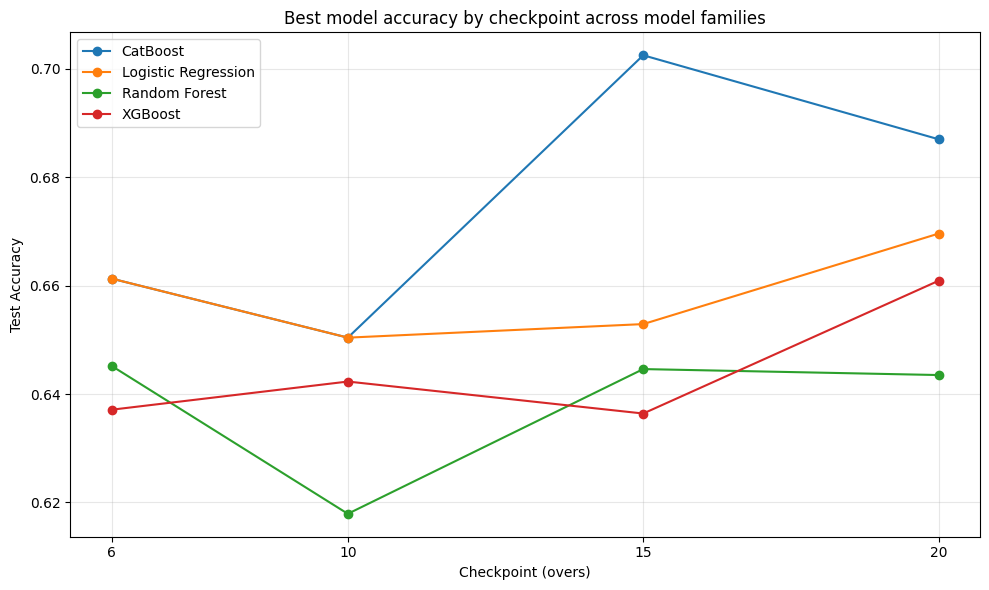

In [136]:
import matplotlib.pyplot as plt
import pandas as pd

# Use family_champions_df from Step 8
plot_df = family_champions_df.copy()

# Sort for clean plotting
plot_df = plot_df.sort_values(["model_family", "checkpoint"])

plt.figure(figsize=(10, 6))

for model_name, grp in plot_df.groupby("model_family"):
    plt.plot(grp["checkpoint"], grp["accuracy"], marker="o", label=model_name)

plt.xticks([6, 10, 15, 20])
plt.xlabel("Checkpoint (overs)")
plt.ylabel("Test Accuracy")
plt.title("Best model accuracy by checkpoint across model families")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Figure 2: CatBoost improvement after tuning

This figure compares baseline and tuned CatBoost performance across checkpoints.  
It shows whether focused hyperparameter tuning improved model performance and where those gains were most meaningful.

In [140]:
# =========================
# Rebuild latest CatBoost results for plotting
# =========================

catboost_tuned_results_df_latest = pd.DataFrame([
    final_row_6,
    final_row_10,
    final_row_15,
    final_row_20
]).sort_values("checkpoint").reset_index(drop=True)

print("Latest tuned CatBoost results being used:")
display(
    catboost_tuned_results_df_latest[
        ["checkpoint", "test_accuracy", "test_f1", "test_auc", "tn", "fp", "fn", "tp"]
    ]
)

Latest tuned CatBoost results being used:


,checkpoint,test_accuracy,test_f1,test_auc,tn,fp,fn,tp
0,6,0.6613,0.6111,0.6978,49,17,25,33
1,10,0.6504,0.5981,0.6761,48,17,26,32
2,15,0.7025,0.7143,0.7072,40,23,13,45
3,20,0.6870,0.6786,0.6813,41,18,18,38


In [141]:
# =========================
# Rebuild CatBoost comparison table using latest results
# =========================

baseline_cat_df_latest = (
    baseline_results_df[baseline_results_df["model"] == "CatBoost"]
    .copy()
    .rename(columns={
        "accuracy": "baseline_accuracy",
        "f1": "baseline_f1",
        "auc": "baseline_auc",
        "tn": "baseline_tn",
        "fp": "baseline_fp",
        "fn": "baseline_fn",
        "tp": "baseline_tp"
    })
)

catboost_compare_df_latest = baseline_cat_df_latest.merge(
    catboost_tuned_results_df_latest,
    on="checkpoint",
    how="inner"
)

catboost_compare_df_latest["accuracy_gain"] = (
    catboost_compare_df_latest["test_accuracy"] - catboost_compare_df_latest["baseline_accuracy"]
).round(4)

catboost_compare_df_latest["f1_gain"] = (
    catboost_compare_df_latest["test_f1"] - catboost_compare_df_latest["baseline_f1"]
).round(4)

catboost_compare_df_latest["auc_gain"] = (
    catboost_compare_df_latest["test_auc"] - catboost_compare_df_latest["baseline_auc"]
).round(4)

print("CatBoost comparison table used for plotting:")
display(
    catboost_compare_df_latest[
        [
            "checkpoint",
            "baseline_accuracy",
            "test_accuracy",
            "accuracy_gain",
            "baseline_f1",
            "test_f1",
            "baseline_auc",
            "test_auc"
        ]
    ].sort_values("checkpoint").reset_index(drop=True)
)

CatBoost comparison table used for plotting:


,checkpoint,baseline_accuracy,test_accuracy,accuracy_gain,baseline_f1,test_f1,baseline_auc,test_auc
0,6,0.6129,0.6613,0.0484,0.5472,0.6111,0.6403,0.6978
1,10,0.5854,0.6504,0.0650,0.5565,0.5981,0.6485,0.6761
2,15,0.5868,0.7025,0.1157,0.5968,0.7143,0.6440,0.7072
3,20,0.6174,0.6870,0.0696,0.5686,0.6786,0.7013,0.6813


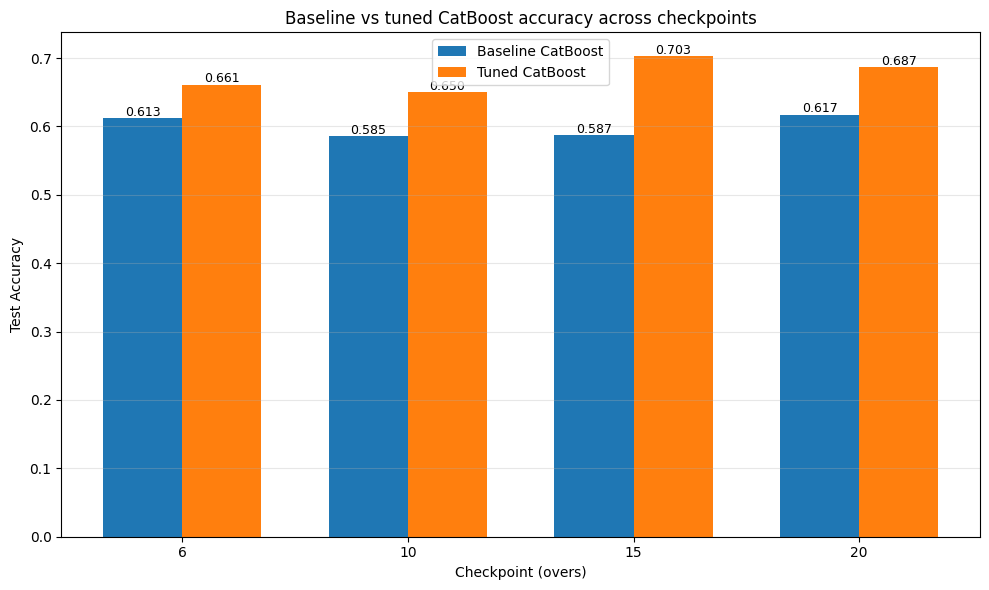

In [143]:
import matplotlib.pyplot as plt
import numpy as np

cb_plot = catboost_compare_df_latest.copy().sort_values("checkpoint")

x = np.arange(len(cb_plot))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, cb_plot["baseline_accuracy"], width, label="Baseline CatBoost")
plt.bar(x + width/2, cb_plot["test_accuracy"], width, label="Tuned CatBoost")

plt.xticks(x, cb_plot["checkpoint"])
plt.xlabel("Checkpoint (overs)")
plt.ylabel("Test Accuracy")
plt.title("Baseline vs tuned CatBoost accuracy across checkpoints")
plt.legend()
plt.grid(axis="y", alpha=0.3)

# optional labels
for i, v in enumerate(cb_plot["baseline_accuracy"]):
    plt.text(i - width/2, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)

for i, v in enumerate(cb_plot["test_accuracy"]):
    plt.text(i + width/2, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

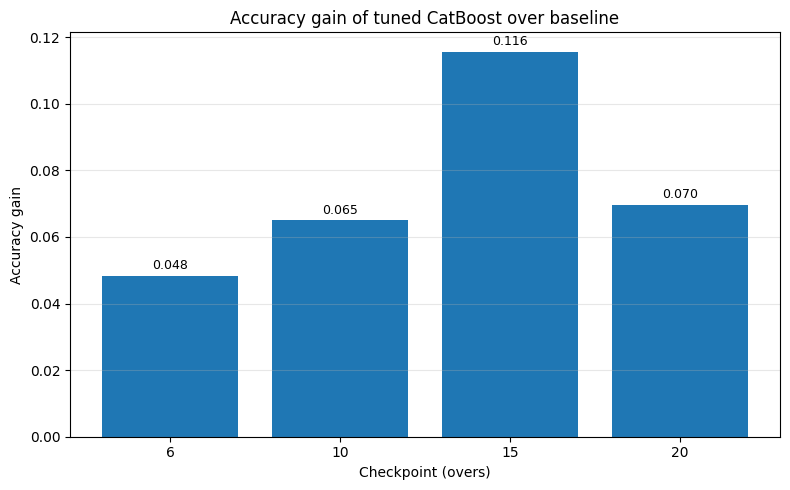

In [144]:
plt.figure(figsize=(8, 5))
plt.bar(cb_plot["checkpoint"].astype(str), cb_plot["accuracy_gain"])

plt.xlabel("Checkpoint (overs)")
plt.ylabel("Accuracy gain")
plt.title("Accuracy gain of tuned CatBoost over baseline")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(cb_plot["accuracy_gain"]):
    plt.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Figure 3: Feature importance for the best overall model

This figure shows the most influential predictors in the final selected model, tuned CatBoost at the 15-over checkpoint.  
It helps interpret which match-state and contextual features contributed most to prediction quality.

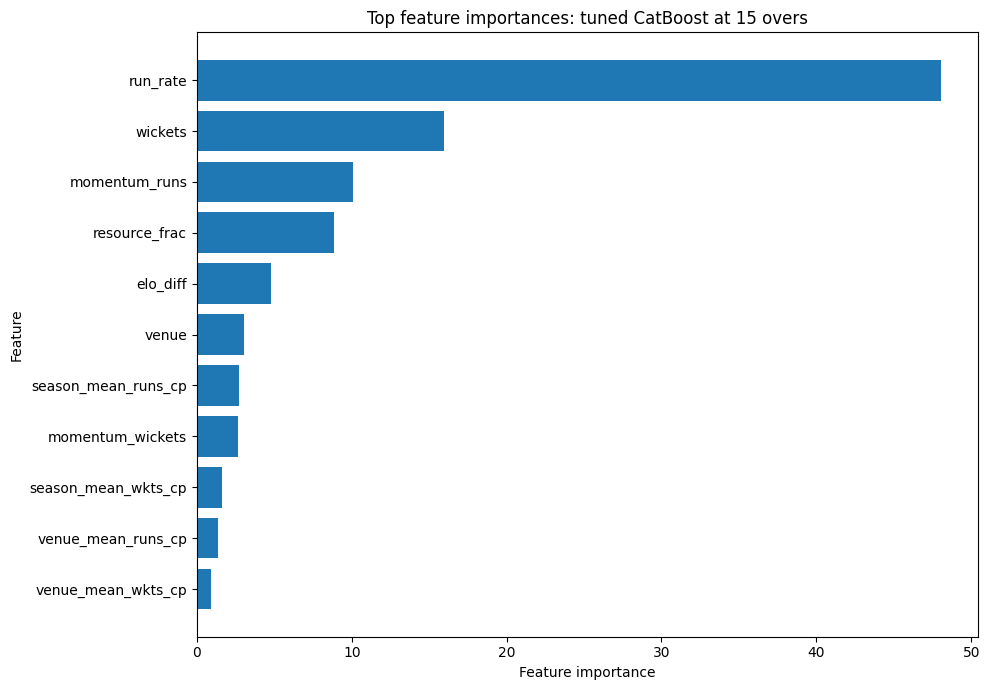

,feature,importance
1,run_rate,48.036142
0,wickets,15.969729
2,momentum_runs,10.054311
5,resource_frac,8.838137
10,elo_diff,4.815471
4,venue,3.028891
8,season_mean_runs_cp,2.749772
3,momentum_wickets,2.656359
9,season_mean_wkts_cp,1.591544
6,venue_mean_runs_cp,1.346121


In [137]:
import matplotlib.pyplot as plt
import pandas as pd

# Rebuild training data for checkpoint 15
train_df_15, test_df_15, X_train_15, y_train_15, X_test_15, y_test_15 = get_checkpoint_data(15)

# Prepare frames the same way as CatBoost training
X_train_15_p, X_test_15_p = prepare_catboost_frames(X_train_15, X_test_15)

# Get feature importances from the final tuned model_15
importances_15 = model_15.get_feature_importance()
feature_names_15 = X_train_15_p.columns.tolist()

fi_df_15 = pd.DataFrame({
    "feature": feature_names_15,
    "importance": importances_15
}).sort_values("importance", ascending=False)

top_n = 12
fi_top = fi_df_15.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top feature importances: tuned CatBoost at 15 overs")
plt.tight_layout()
plt.show()

display(fi_df_15.head(15))

### Figure 4: Confusion matrix for the best overall model

This figure shows how the final best model, tuned CatBoost at the 15-over checkpoint, classified bat-first wins and losses on the test set.  
It provides a clearer picture of the model’s error behaviour than accuracy alone.

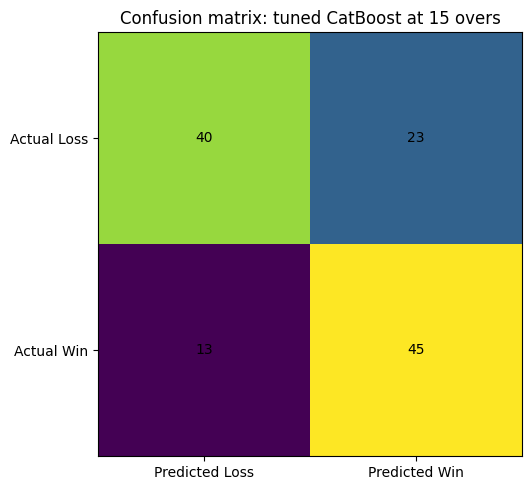

In [138]:
import matplotlib.pyplot as plt
import numpy as np

# Best overall model from Step 8 is CatBoost at checkpoint 15
cm = np.array([[40, 23],
               [13, 45]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted Loss", "Predicted Win"])
ax.set_yticklabels(["Actual Loss", "Actual Win"])
ax.set_title("Confusion matrix: tuned CatBoost at 15 overs")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### Figure 5: Final selected winner accuracy by checkpoint

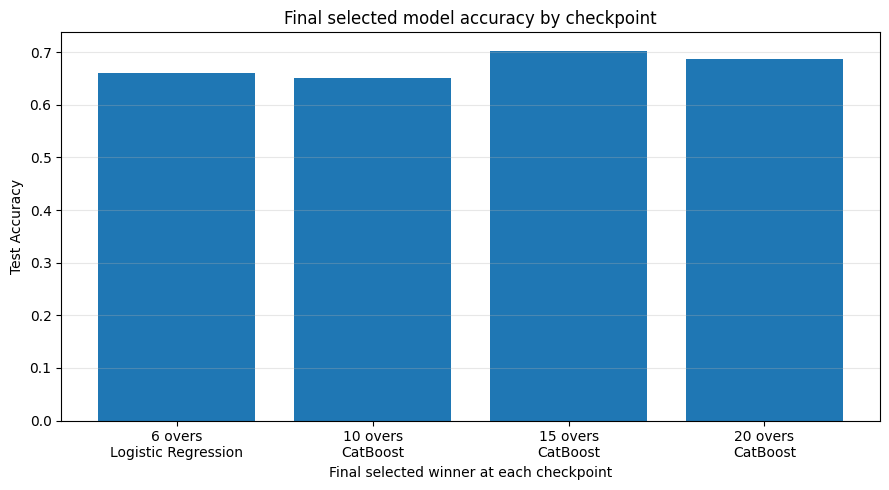

In [139]:
import matplotlib.pyplot as plt

winner_df = final_checkpoint_winners_df.copy().sort_values("checkpoint")

labels = [
    f"{row['checkpoint']} overs\n{row['model_family']}"
    for _, row in winner_df.iterrows()
]

plt.figure(figsize=(9, 5))
plt.bar(labels, winner_df["accuracy"])
plt.ylabel("Test Accuracy")
plt.xlabel("Final selected winner at each checkpoint")
plt.title("Final selected model accuracy by checkpoint")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()